# Colab EDA Setup

Run these cells from top to bottom in Colab to clone the repo, verify the branch, mount Drive, and load the presentation dataset into a pandas DataFrame.

In [24]:
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

REPO_URL = "https://github.com/Avi161/ACSolverX.git"
BRANCH = "test/eda"

print("1. Repo setup")
print(f"Environment: {'Google Colab' if IN_COLAB else 'local'}")

if IN_COLAB:
    REPO_DIR = Path("/content/ACSolverX")
    if REPO_DIR.exists():
        print(f"Repo already exists at {REPO_DIR}")
    else:
        print(f"Cloning {REPO_URL} into {REPO_DIR}")
        !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}

    print(f"\nChecking out branch: {BRANCH}")
    !git fetch origin
    !git checkout {BRANCH}
    !git pull --ff-only origin {BRANCH}

    print("\nInstalling CUDA-ready repo dependencies:")
    %pip install -q -r requirements-cuda.txt
else:
    # Running locally: the notebook lives in <repo>/experiments, so find the repo
    # root by walking up until we see requirements.txt, then cd there.
    REPO_DIR = Path.cwd()
    while REPO_DIR != REPO_DIR.parent and not (REPO_DIR / "requirements.txt").exists():
        REPO_DIR = REPO_DIR.parent

    %cd {REPO_DIR}
    print(f"Using local repo at {REPO_DIR}")
    print("(skipping clone / branch checkout / pull so local edits are preserved)")

    print("\nInstalling EDA dependencies into the active kernel:")
    %pip install -q numpy pandas matplotlib seaborn

print("\nCurrent branch:")
!git branch --show-current

print("\nGit status:")
!git status --short --branch

print("\nDependency setup finished.")

1. Repo setup
Environment: local
/Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/ACSolverX
Using local repo at /Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/ACSolverX
(skipping clone / branch checkout / pull so local edits are preserved)

Installing EDA dependencies into the active kernel:


/Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Note: you may need to restart the kernel to use updated packages.

Current branch:
test/eda

Git status:
## test/eda...origin/test/eda
 M .gitignore
 M CLAUDE.md
 M experiments/eda.ipynb
?? experiments/CLAUDE_ROUGH_PLAN.md

Dependency setup finished.


## 2. Import Analysis Libraries

In [25]:
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("2. Imports loaded")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

2. Imports loaded
pandas version: 2.3.3
numpy version: 2.0.2


In [26]:
if IN_COLAB:
    from google.colab import drive

    DRIVE_ROOT = Path("/content/drive/MyDrive")

    print("3. Mounting Google Drive")
    drive.mount("/content/drive")
    print(f"Drive mounted: {DRIVE_ROOT.exists()}")

    if DRIVE_ROOT.exists():
        print("\nFirst 10 items in MyDrive:")
        for path in sorted(DRIVE_ROOT.iterdir())[:10]:
            print(f"- {path.name}")
else:
    print("3. Skipping Google Drive mount (not running in Colab)")

3. Skipping Google Drive mount (not running in Colab)


# EDA

In [27]:
DATA_PATH = Path("data/all_presentations_len_8_to_19_GS_solved_copy2.csv")

print("4. Loading presentation dataset")
print(f"Current working directory: {Path.cwd()}")
print(f"Loading dataset from: {DATA_PATH.resolve()}")
print(f"File exists: {DATA_PATH.exists()}")

records = []

with DATA_PATH.open(newline="") as file:
    reader = csv.reader(file)
    header = next(reader)
    print(f"CSV header: {header}")

    for row_number, row in enumerate(reader, start=2):
        if not row:
            continue

        if len(row) < 4:
            raise ValueError(
                f"Row {row_number} has {len(row)} columns; expected at least 4."
            )

        r1, r2, nodes_visited, path_length, *path = row
        records.append(
            {
                "r1": r1,
                "r2": r2,
                "Nodes Visited": nodes_visited,
                "Path Length": path_length,
                "Path": path,
            }
        )

df = pd.DataFrame(records)
df["Nodes Visited"] = pd.to_numeric(df["Nodes Visited"], downcast="integer")
df["Path Length"] = pd.to_numeric(df["Path Length"], downcast="integer")

print(f"\nLoaded DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\nData types:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isna().sum())

print("\nPath Length summary:")
print(df["Path Length"].describe())

print("\nPreview:")
display(df.head())

4. Loading presentation dataset
Current working directory: /Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/ACSolverX
Loading dataset from: /Users/avigyapaudel/Documents/Obsidian Vault/surf/codebase/ACSolverX/data/all_presentations_len_8_to_19_GS_solved_copy2.csv
File exists: True
CSV header: ['r1', 'r2', 'Nodes Visited', 'Path Length', 'Path']



Loaded DataFrame shape: (17635, 5)
Columns: ['r1', 'r2', 'Nodes Visited', 'Path Length', 'Path']

Data types:
r1               object
r2               object
Nodes Visited     int16
Path Length       int16
Path             object
dtype: object

Missing values by column:
r1               0
r2               0
Nodes Visited    0
Path Length      0
Path             0
dtype: int64

Path Length summary:
count    17635.000000
mean        10.486532
std         17.241073
min         -1.000000
25%         -1.000000
50%          7.000000
75%         12.000000
max        349.000000
Name: Path Length, dtype: float64

Preview:


,r1,r2,Nodes Visited,Path Length,Path
0,xxxyy,xyyxY,5,4,"[xxxyy, xyyxY, xy, xxxyy, xy, xxy, x, xy, x, y]"
1,xxyxy,xyyxY,8,5,"[xxyxy, xyyxY, xxyxy, xyxYXy, xxy, xxyxy, xy, ..."
2,xxyXy,xyXYY,7,5,"[xxyXy, xyXYY, xyyy, xyXYY, xyy, xyyy, y, xyy,..."
3,xxyXY,xyXYY,4,3,"[xxyXY, xyXYY, xy, xxyXY, y, xy, x, y]"
4,xxxyy,xxyyXY,5,4,"[xxxyy, xxyyXY, xxy, xxxyy, xy, xxy, x, xy, x, y]"


In [28]:
HIST_BINS = 50

print("EDA dataset shape:", df.shape)
print("Available columns:", list(df.columns))

is_solved = df["Path Length"] >= 0
solved_df = df.loc[is_solved].copy()
unsolved_df = df.loc[~is_solved].copy()

n_total = len(df)
n_solved = len(solved_df)
n_unsolved = len(unsolved_df)
solved_rate = n_solved / n_total * 100
unsolved_rate = n_unsolved / n_total * 100

print("\nSolved vs unsolved split")
print(f"Total rows: {n_total:,}")
print(f"Solved rows (Path Length >= 0): {n_solved:,} ({solved_rate:.2f}%)")
print(f"Unsolved rows (Path Length == -1): {n_unsolved:,} ({unsolved_rate:.2f}%)")
print(f"Solved-only row count used for stats and plots: {n_solved:,}")

expected_path_items = 2 * (solved_df["Path Length"] + 1)
actual_path_items = solved_df["Path"].map(len)
path_length_mismatches = (actual_path_items != expected_path_items).sum()
print("\nPath encoding check on solved rows")
print(f"Rows where len(Path) != 2 * (Path Length + 1): {path_length_mismatches:,}")

summary_percentiles = [0.90, 0.95, 0.99]

def print_summary(series, label):
    print(f"\n{label} stats on solved rows only")
    print(f"mean: {series.mean():.4f}")
    print(f"median: {series.median():.4f}")
    print(f"std: {series.std():.4f}")
    print(f"min: {series.min():.4f}")
    print(f"max: {series.max():.4f}")
    for q, value in series.quantile(summary_percentiles).items():
        print(f"p{int(q * 100)}: {value:.4f}")

path_lengths = solved_df["Path Length"]
nodes_visited = solved_df["Nodes Visited"]

print_summary(path_lengths, "Path Length")
print_summary(nodes_visited, "Nodes Visited")

print("\nTail counts on solved rows")
for threshold in [20, 50, 100]:
    count = (path_lengths > threshold).sum()
    pct = count / n_solved * 100
    print(f"Path Length > {threshold}: {count:,} ({pct:.2f}%)")

correlation = nodes_visited.corr(path_lengths)
print("\nNodes Visited vs Path Length")
print(f"Pearson correlation coefficient: {correlation:.4f}")

EDA dataset shape: (17635, 5)
Available columns: ['r1', 'r2', 'Nodes Visited', 'Path Length', 'Path']

Solved vs unsolved split
Total rows: 17,635
Solved rows (Path Length >= 0): 12,681 (71.91%)
Unsolved rows (Path Length == -1): 4,954 (28.09%)
Solved-only row count used for stats and plots: 12,681

Path encoding check on solved rows
Rows where len(Path) != 2 * (Path Length + 1): 0

Path Length stats on solved rows only
mean: 14.9739
median: 9.0000
std: 18.4852
min: 2.0000
max: 349.0000
p90: 32.0000
p95: 47.0000
p99: 92.0000

Nodes Visited stats on solved rows only
mean: 335.7018
median: 13.0000
std: 1072.1338
min: 3.0000
max: 9989.0000
p90: 552.0000
p95: 2206.0000
p99: 5281.0000

Tail counts on solved rows
Path Length > 20: 2,345 (18.49%)
Path Length > 50: 515 (4.06%)
Path Length > 100: 99 (0.78%)

Nodes Visited vs Path Length
Pearson correlation coefficient: 0.5730


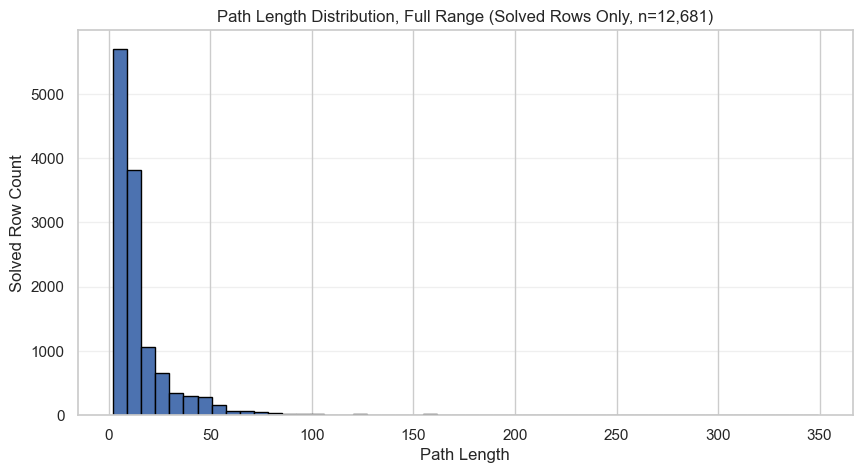

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(path_lengths, bins=HIST_BINS, edgecolor="black")
plt.title(f"Path Length Distribution, Full Range (Solved Rows Only, n={n_solved:,})")
plt.xlabel("Path Length")
plt.ylabel("Solved Row Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

Path Length 99th percentile: 92.0000
Clipped histogram upper bound: 92
Rows at or above clipped upper bound: 129 (1.02%)


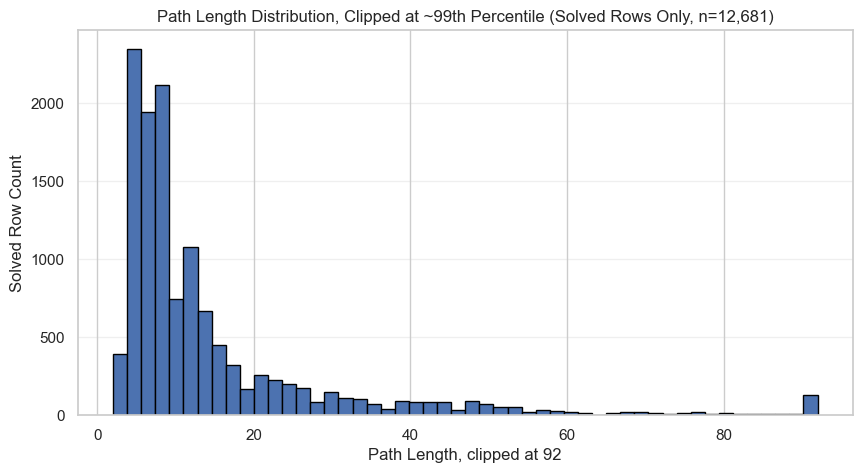

In [30]:
path_length_p99 = path_lengths.quantile(0.99)
path_length_clip_max = int(np.ceil(path_length_p99))
path_lengths_clipped = path_lengths.clip(upper=path_length_clip_max)

print(f"Path Length 99th percentile: {path_length_p99:.4f}")
print(f"Clipped histogram upper bound: {path_length_clip_max}")
print(
    f"Rows at or above clipped upper bound: "
    f"{(path_lengths >= path_length_clip_max).sum():,} "
    f"({(path_lengths >= path_length_clip_max).mean() * 100:.2f}%)"
)

plt.figure(figsize=(10, 5))
plt.hist(path_lengths_clipped, bins=HIST_BINS, edgecolor="black")
plt.title(
    f"Path Length Distribution, Clipped at ~99th Percentile "
    f"(Solved Rows Only, n={n_solved:,})"
)
plt.xlabel(f"Path Length, clipped at {path_length_clip_max}")
plt.ylabel("Solved Row Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

Nodes Visited rows used for log-scale histogram: 12,681
Nodes Visited rows excluded because value <= 0: 0


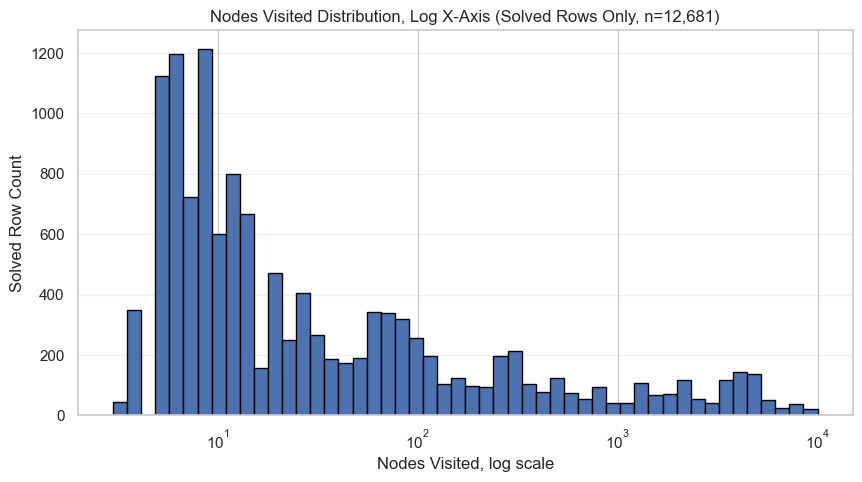

In [31]:
positive_nodes = nodes_visited[nodes_visited > 0]
non_positive_nodes = (nodes_visited <= 0).sum()

print(f"Nodes Visited rows used for log-scale histogram: {len(positive_nodes):,}")
print(f"Nodes Visited rows excluded because value <= 0: {non_positive_nodes:,}")

node_bins = np.logspace(
    np.log10(positive_nodes.min()),
    np.log10(positive_nodes.max()),
    HIST_BINS + 1,
)

plt.figure(figsize=(10, 5))
plt.hist(positive_nodes, bins=node_bins, edgecolor="black")
plt.xscale("log")
plt.title(f"Nodes Visited Distribution, Log X-Axis (Solved Rows Only, n={n_solved:,})")
plt.xlabel("Nodes Visited, log scale")
plt.ylabel("Solved Row Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

Pearson correlation coefficient: 0.5730


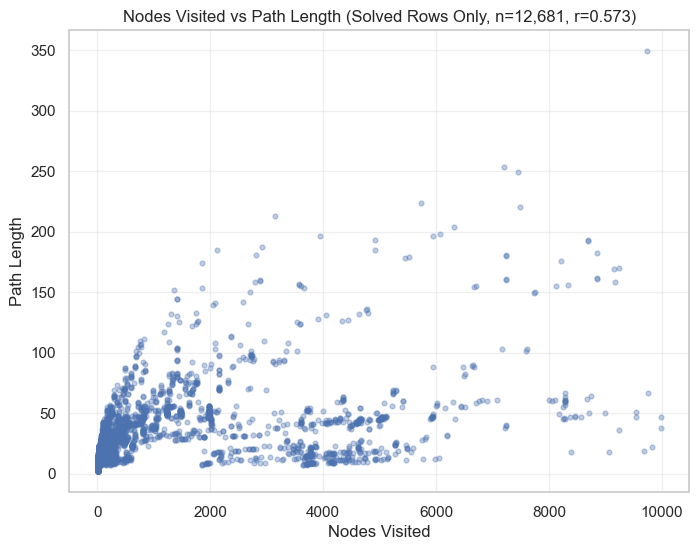

In [32]:
print(f"Pearson correlation coefficient: {correlation:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(nodes_visited, path_lengths, alpha=0.35, s=12)
plt.title(
    f"Nodes Visited vs Path Length (Solved Rows Only, n={n_solved:,}, r={correlation:.3f})"
)
plt.xlabel("Nodes Visited")
plt.ylabel("Path Length")
plt.grid(alpha=0.3)
plt.show()

## Length Profile / Valley-Crossing Signal

For each solved path, compute the total relator length at every state: `len(relator_1) + len(relator_2)`. Then compare each profile to its starting length to measure whether the path ever rises above the start and by how much.

In [33]:
def relator_pair_length(relator_1, relator_2):
    return len(relator_1) + len(relator_2)


def length_profile_from_path(path):
    if len(path) % 2 != 0:
        raise ValueError(f"Path has odd number of relators: {len(path)}")

    return [
        relator_pair_length(path[i], path[i + 1])
        for i in range(0, len(path), 2)
    ]


length_profile_records = []

for row_index, row in solved_df.iterrows():
    profile = length_profile_from_path(row["Path"])
    start_length = relator_pair_length(row["r1"], row["r2"])
    profile_start_length = profile[0]

    if profile_start_length != start_length:
        raise ValueError(
            f"Row {row_index} starts at profile length {profile_start_length}, "
            f"but r1/r2 length is {start_length}."
        )

    profile_array = np.array(profile)
    deltas_from_start = profile_array - start_length
    step_diffs = np.diff(profile_array)

    states_above_start = int((deltas_from_start > 0).sum())
    max_rise_above_start = int(deltas_from_start.max())

    length_profile_records.append(
        {
            "row_index": row_index,
            "r1": row["r1"],
            "r2": row["r2"],
            "Path Length": row["Path Length"],
            "Start Total Length": start_length,
            "End Total Length": int(profile_array[-1]),
            "Min Total Length": int(profile_array.min()),
            "Max Total Length": int(profile_array.max()),
            "Max Rise Above Start": max_rise_above_start,
            "Ever Above Start": max_rise_above_start > 0,
            "States Above Start": states_above_start,
            "Fraction States Above Start": states_above_start / len(profile),
            "Monotone Nonincreasing": bool((step_diffs <= 0).all()),
            "Has Step Increase": bool((step_diffs > 0).any()),
            "Max Single-Step Increase": int(step_diffs.max()) if len(step_diffs) else 0,
            "Length Profile": profile,
        }
    )

length_profile_df = pd.DataFrame(length_profile_records)

print("Length-profile analysis uses solved rows only")
print(f"Solved rows analyzed: {len(length_profile_df):,}")
print(f"Original solved row count: {n_solved:,}")
print(f"All solved rows included: {len(length_profile_df) == n_solved}")

n_ever_above_start = int(length_profile_df["Ever Above Start"].sum())
pct_ever_above_start = n_ever_above_start / n_solved * 100
n_never_above_start = n_solved - n_ever_above_start
pct_never_above_start = n_never_above_start / n_solved * 100

n_monotone_nonincreasing = int(length_profile_df["Monotone Nonincreasing"].sum())
pct_monotone_nonincreasing = n_monotone_nonincreasing / n_solved * 100
n_has_step_increase = int(length_profile_df["Has Step Increase"].sum())
pct_has_step_increase = n_has_step_increase / n_solved * 100

total_states = int((length_profile_df["Path Length"] + 1).sum())
total_states_above_start = int(length_profile_df["States Above Start"].sum())
pct_states_above_start = total_states_above_start / total_states * 100

print("\nHow often paths rise above the start")
print(
    f"Paths that ever rise above start: "
    f"{n_ever_above_start:,} ({pct_ever_above_start:.2f}%)"
)
print(
    f"Paths that never rise above start: "
    f"{n_never_above_start:,} ({pct_never_above_start:.2f}%)"
)
print(
    f"States above start across all solved paths: "
    f"{total_states_above_start:,} / {total_states:,} ({pct_states_above_start:.2f}%)"
)

print("\nStepwise monotonicity")
print(
    f"Monotone nonincreasing length profiles: "
    f"{n_monotone_nonincreasing:,} ({pct_monotone_nonincreasing:.2f}%)"
)
print(
    f"Profiles with at least one step increase: "
    f"{n_has_step_increase:,} ({pct_has_step_increase:.2f}%)"
)

rise = length_profile_df["Max Rise Above Start"]
print("\nMax rise above start summary")
print(f"mean: {rise.mean():.4f}")
print(f"median: {rise.median():.4f}")
print(f"std: {rise.std():.4f}")
print(f"min: {rise.min():.4f}")
print(f"max: {rise.max():.4f}")
for q, value in rise.quantile([0.90, 0.95, 0.99]).items():
    print(f"p{int(q * 100)}: {value:.4f}")

print("\nTail counts for max rise above start")
for threshold in [0, 2, 5, 10, 20]:
    count = int((rise > threshold).sum())
    pct = count / n_solved * 100
    print(f"Max Rise Above Start > {threshold}: {count:,} ({pct:.2f}%)")

print("\nRows with largest rise above start")
display(
    length_profile_df.sort_values("Max Rise Above Start", ascending=False)[
        [
            "row_index",
            "r1",
            "r2",
            "Path Length",
            "Start Total Length",
            "Max Total Length",
            "Max Rise Above Start",
            "States Above Start",
            "Monotone Nonincreasing",
        ]
    ].head(10)
)

Length-profile analysis uses solved rows only
Solved rows analyzed: 12,681
Original solved row count: 12,681
All solved rows included: True

How often paths rise above the start
Paths that ever rise above start: 3,365 (26.54%)
Paths that never rise above start: 9,316 (73.46%)
States above start across all solved paths: 37,795 / 202,565 (18.66%)

Stepwise monotonicity
Monotone nonincreasing length profiles: 5,424 (42.77%)
Profiles with at least one step increase: 7,257 (57.23%)

Max rise above start summary
mean: 0.8931
median: 0.0000
std: 1.8552
min: 0.0000
max: 11.0000
p90: 4.0000
p95: 5.0000
p99: 8.0000

Tail counts for max rise above start
Max Rise Above Start > 0: 3,365 (26.54%)
Max Rise Above Start > 2: 1,878 (14.81%)
Max Rise Above Start > 5: 592 (4.67%)
Max Rise Above Start > 10: 9 (0.07%)
Max Rise Above Start > 20: 0 (0.00%)

Rows with largest rise above start


,row_index,r1,r2,Path Length,Start Total Length,Max Total Length,Max Rise Above Start,States Above Start,Monotone Nonincreasing
9712,13161,xxyxyXXY,xxyxYxyXy,12,17,28,11,5,False
9798,13312,xxyxyXXY,xyxyxyyxY,11,17,28,11,5,False
4538,5401,xxyXyXY,xyyXyxyyy,47,16,27,11,20,False
9794,13298,xxyxyXXY,xxYYxyXyy,13,17,28,11,5,False
9670,13094,xxyxyXXY,xxxyyxYXy,12,17,28,11,5,False
6080,7408,xxxyxxYY,xyxyxYxYY,82,17,28,11,60,False
1284,1405,xxyxYXY,xyyXyXYY,60,15,26,11,43,False
6028,7317,xxxyxxyy,xyyyyxYxY,16,17,28,11,11,False
6056,7362,xxxyxxYY,xxyxyXYXY,81,17,28,11,60,False
7021,9119,xxxyXXYY,xxxxxYYXY,39,17,27,10,16,False


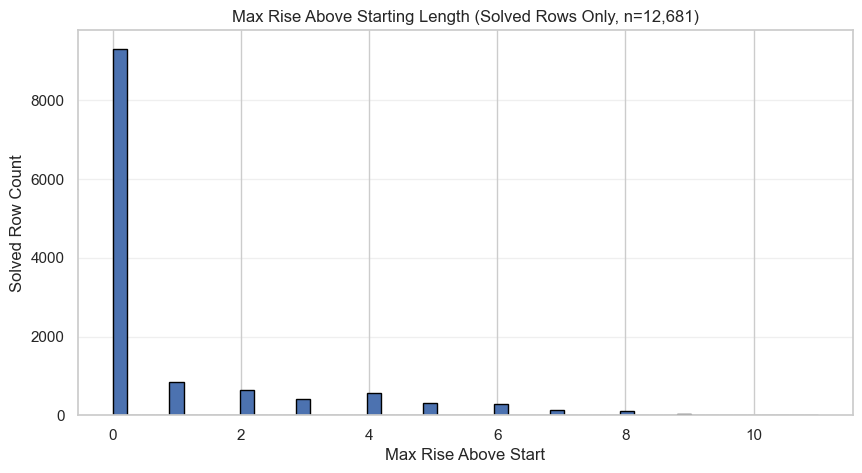

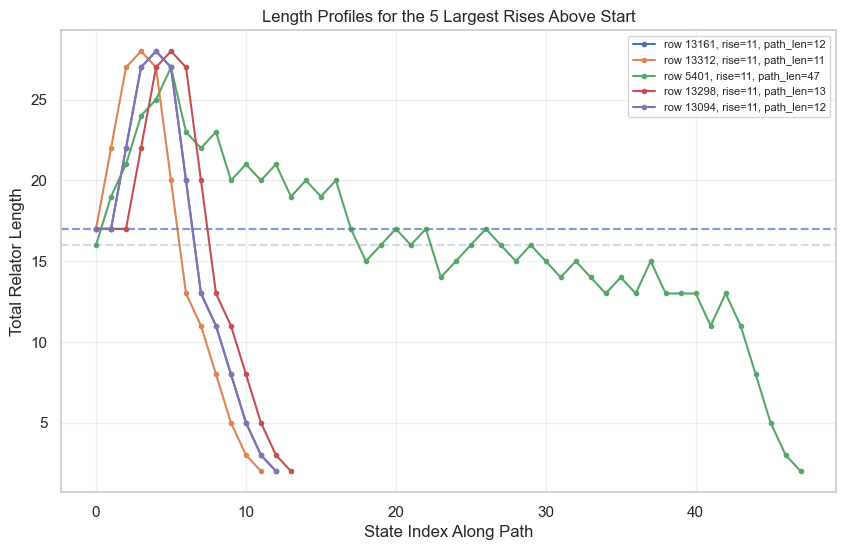

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(length_profile_df["Max Rise Above Start"], bins=HIST_BINS, edgecolor="black")
plt.title(f"Max Rise Above Starting Length (Solved Rows Only, n={n_solved:,})")
plt.xlabel("Max Rise Above Start")
plt.ylabel("Solved Row Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

highest_rise_examples = length_profile_df.sort_values(
    "Max Rise Above Start", ascending=False
).head(5)

plt.figure(figsize=(10, 6))
for _, row in highest_rise_examples.iterrows():
    profile = row["Length Profile"]
    x = range(len(profile))
    label = (
        f"row {row['row_index']}, "
        f"rise={row['Max Rise Above Start']}, "
        f"path_len={row['Path Length']}"
    )
    plt.plot(x, profile, marker="o", markersize=3, linewidth=1.5, label=label)
    plt.axhline(row["Start Total Length"], linestyle="--", alpha=0.25)

plt.title("Length Profiles for the 5 Largest Rises Above Start")
plt.xlabel("State Index Along Path")
plt.ylabel("Total Relator Length")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## Raw Sanity EDA: Initial Total Relator Length vs Greedy Path Length

Before building any canon plumbing, a raw sanity check straight off the CSV (no canon needed). The initial total relator length is just `len(r1) + len(r2)` from the original presentation.

- **Scatter:** initial total relator length vs greedy `Path Length`, with **solved** rows in blue and **unsolved** rows (`Path Length == -1`) drawn as a red strip below the axis (they have no path).
- **Path Length distribution** over solved rows.
- **Initial total relator length by outcome** (solved vs unsolved overlaid) and the **unsolved rate per initial total length**, to see how strongly starting relator length drives whether a presentation stays unsolved.

Total rows:    17,635
Solved rows:   12,681 (71.91%)
Unsolved rows: 4,954 (28.09%)
Initial total relator length range: 10 to 17


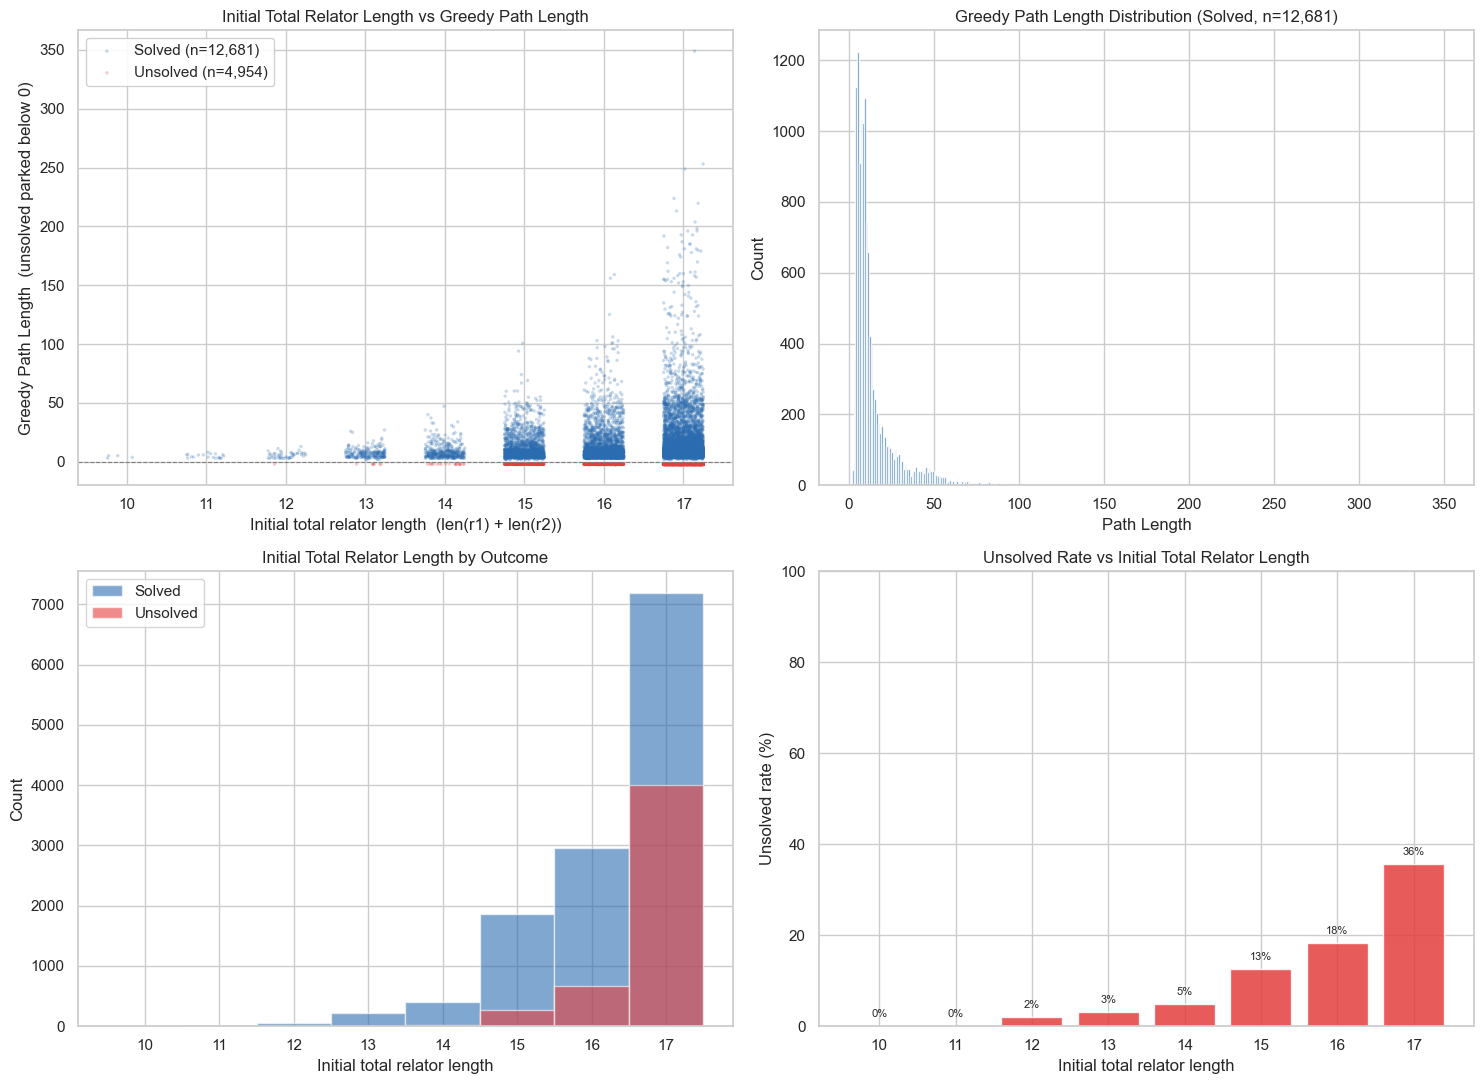


Pearson r (initial total length vs path length, solved only): 0.140


In [35]:
df["Initial Total Length"] = df["r1"].str.len() + df["r2"].str.len()

solved_mask = df["Path Length"] >= 0
solved = df.loc[solved_mask]
unsolved = df.loc[~solved_mask]

print(f"Total rows:    {len(df):,}")
print(f"Solved rows:   {len(solved):,} ({len(solved) / len(df) * 100:.2f}%)")
print(f"Unsolved rows: {len(unsolved):,} ({len(unsolved) / len(df) * 100:.2f}%)")
print(
    "Initial total relator length range: "
    f"{int(df['Initial Total Length'].min())} to {int(df['Initial Total Length'].max())}"
)

rng = np.random.default_rng(0)
SOLVED_C = "#2b6cb0"
UNSOLVED_C = "#e53e3e"
UNSOLVED_STRIP_Y = -2  # where the (path-less) unsolved rows are parked in the scatter

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1) Scatter: initial total relator length vs greedy path length (jittered, discrete data)
ax = axes[0, 0]
ax.scatter(
    solved["Initial Total Length"] + rng.uniform(-0.25, 0.25, size=len(solved)),
    solved["Path Length"] + rng.uniform(-0.25, 0.25, size=len(solved)),
    s=6, alpha=0.25, c=SOLVED_C, edgecolors="none",
    label=f"Solved (n={len(solved):,})",
)
ax.scatter(
    unsolved["Initial Total Length"] + rng.uniform(-0.25, 0.25, size=len(unsolved)),
    np.full(len(unsolved), UNSOLVED_STRIP_Y) + rng.uniform(-0.3, 0.3, size=len(unsolved)),
    s=6, alpha=0.25, c=UNSOLVED_C, edgecolors="none",
    label=f"Unsolved (n={len(unsolved):,})",
)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Initial Total Relator Length vs Greedy Path Length")
ax.set_xlabel("Initial total relator length  (len(r1) + len(r2))")
ax.set_ylabel("Greedy Path Length  (unsolved parked below 0)")
ax.legend(loc="upper left", framealpha=0.9)

# 2) Path length distribution (solved only)
ax = axes[0, 1]
ax.hist(
    solved["Path Length"],
    bins=range(0, int(solved["Path Length"].max()) + 2),
    color=SOLVED_C, alpha=0.85,
)
ax.set_title(f"Greedy Path Length Distribution (Solved, n={len(solved):,})")
ax.set_xlabel("Path Length")
ax.set_ylabel("Count")

# 3) Initial total relator length distribution, solved vs unsolved
ax = axes[1, 0]
lo = int(df["Initial Total Length"].min())
hi = int(df["Initial Total Length"].max())
bins = np.arange(lo - 0.5, hi + 1.5, 1)
ax.hist(solved["Initial Total Length"], bins=bins, color=SOLVED_C, alpha=0.6, label="Solved")
ax.hist(unsolved["Initial Total Length"], bins=bins, color=UNSOLVED_C, alpha=0.6, label="Unsolved")
ax.set_title("Initial Total Relator Length by Outcome")
ax.set_xlabel("Initial total relator length")
ax.set_ylabel("Count")
ax.legend()

# 4) Unsolved rate per initial total relator length
ax = axes[1, 1]
counts = df.groupby("Initial Total Length").size()
unsolved_counts = (
    unsolved.groupby("Initial Total Length").size().reindex(counts.index, fill_value=0)
)
unsolved_frac = unsolved_counts / counts
ax.bar(unsolved_frac.index, unsolved_frac.values * 100, color=UNSOLVED_C, alpha=0.85)
ax.set_title("Unsolved Rate vs Initial Total Relator Length")
ax.set_xlabel("Initial total relator length")
ax.set_ylabel("Unsolved rate (%)")
ax.set_ylim(0, 100)
for x, frac in unsolved_frac.items():
    ax.text(x, frac * 100 + 1.5, f"{frac * 100:.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

corr = solved["Initial Total Length"].corr(solved["Path Length"])
print(f"\nPearson r (initial total length vs path length, solved only): {corr:.3f}")

# Shared Prep — State Table & Integrity Checks

Everything below reuses two artifacts built **once** here, plus one framing held in every tab.

**Framing (non-negotiable):** total relator length is the *best currently-known* heuristic. We characterise where it **works** and where it is **uninformative**, to scope the headroom a learned distance-until-trivialization (d-o-t) heuristic *could* occupy. We do **not** assume greedy is "bad" or that d-o-t will beat length — that is unproven. Also: greedy `remaining_dot = Path Length − step` is the **greedy** distance to the trivial state, an **upper bound** on the true d-o-t (greedy may be suboptimal), so any disagreement we measure is a *lower* bound on label noise.

- **`on_path_states`** (PREP-B): one row per on-path state across all 12,681 solved paths, with `total_len`, `asym`, `remaining_dot`, `state_key`, and `init_len_band`. The data is 63 % length-17, so any global metric is effectively a length-17 metric — we **stratify by band** {10–13, 14–15, 16, 17} throughout.
- **PREP-A**: validates the invariants the rest relies on — path-length identity, trivial terminal, and *exactly one substitution per step* (checked as a **multiset**, since the stored pair is ordered shortest-first and can swap which relator is listed first). If any check FAILs, stop and fix parsing before trusting later tabs.

In [36]:
# ===== PREP-B: build on_path_states (one row per on-path state) + init_len_band =====
import numpy as np, pandas as pd

# init_len_band defined ONCE, reused everywhere (data is 63% length-17, so global == length-17)
BAND_ORDER = ["10-13", "14-15", "16", "17"]
def to_band(L):
    if L <= 13: return "10-13"
    if L <= 15: return "14-15"
    if L == 16: return "16"
    return "17"

# KEY CONVENTION: the solver stores each state as REDUCED relators ordered shortest-first.
# This is NOT canonical_pair_nj form (relators are not rotation/inverse-minimized), but it is
# empirically a faithful 1:1 identifier of the true canonical class for THIS dataset
# (verified in the neighbor-resolution tab: 25,209 stored states == 25,209 canonical_pair_nj
# classes, zero d-o-t disagreement). So `state_key` is a valid within-dataset canonical id;
# joining OTHER sources (env / PPO / 1190MS) would first require canonicalizing via
# canonical_pair_nj. remaining_dot = Path Length - step is greedy distance-to-trivial: an
# UPPER BOUND on the true d-o-t (greedy may be suboptimal).
rows = []
for path_id, r1, r2, plen, path in zip(
    solved_df.index, solved_df["r1"], solved_df["r2"],
    solved_df["Path Length"], solved_df["Path"]
):
    init_total = len(r1) + len(r2)
    band = to_band(init_total)
    for t in range(plen + 1):
        a, b = path[2*t], path[2*t+1]
        la, lb = len(a), len(b)
        rows.append((
            path_id, t, a, b, a + "|" + b, la, lb, la + lb, abs(la - lb),
            plen - t, init_total, band, plen,
        ))

on_path_states = pd.DataFrame(rows, columns=[
    "path_id","step_index","r1_str","r2_str","state_key","len_r1","len_r2",
    "total_len","asym","remaining_dot","init_total_len","init_len_band","path_length"])
on_path_states["init_len_band"] = pd.Categorical(
    on_path_states["init_len_band"], categories=BAND_ORDER, ordered=True)

print("on_path_states shape:", on_path_states.shape)
print("unique state keys:", on_path_states["state_key"].nunique())
print("states per band:\n", on_path_states["init_len_band"].value_counts().reindex(BAND_ORDER).to_string())
print("\nexpected total states (sum path_len+1):", int((solved_df["Path Length"]+1).sum()))

on_path_states shape: (202565, 13)
unique state keys: 25209
states per band:
 init_len_band
10-13      2292
14-15     27930
16        42672
17       129671

expected total states (sum path_len+1): 202565


In [37]:
# ===== PREP-A: integrity / assumption checks (0 = pass; stop if any FAIL) =====
checks = {}

# 1. len(Path) == 2*(Path Length + 1)
checks["len(Path)==2*(PL+1)"] = int((solved_df["Path"].map(len) != 2*(solved_df["Path Length"]+1)).sum())

# 2. terminal state is two single letters
term = on_path_states.sort_values(["path_id","step_index"]).groupby("path_id").tail(1)
checks["terminal not (1,1)"] = int(((term["len_r1"]!=1) | (term["len_r2"]!=1)).sum())

# 3. exactly one substitution per step — checked as a MULTISET (the pair is ordered
#    shortest-first and can swap which relator is listed first, so a slot-wise diff is wrong)
def changed_count(a, b, ap, bp):
    nxt = [ap, bp]; inter = 0
    for x in (a, b):
        if x in nxt: nxt.remove(x); inter += 1
    return 2 - inter

from collections import Counter
changed_hist = Counter(); viol_one_move = 0
for r1, r2, plen, path in zip(solved_df["r1"], solved_df["r2"], solved_df["Path Length"], solved_df["Path"]):
    states = [(path[2*t], path[2*t+1]) for t in range(plen+1)]
    for (a, b), (ap, bp) in zip(states, states[1:]):
        c = changed_count(a, b, ap, bp); changed_hist[c] += 1
        if c != 1: viol_one_move += 1
checks["steps changing !=1 relator"] = viol_one_move

# 4. no empty/NaN among solved core columns
checks["NaN in solved core cols"] = int(solved_df[["r1","r2","Path Length","Nodes Visited"]].isna().sum().sum())

print("=== PREP-A integrity (0 = pass) ===")
for k, v in checks.items():
    print(f"  {'PASS' if v==0 else 'FAIL'}  {k}: {v}")
print("\nrelators changed per step (should be all 1):", dict(sorted(changed_hist.items())))
print("total transitions:", sum(changed_hist.values()))
assert all(v == 0 for v in checks.values()), "integrity check FAILED — fix parsing before trusting later tabs"

=== PREP-A integrity (0 = pass) ===
  PASS  len(Path)==2*(PL+1): 0
  PASS  terminal not (1,1): 0
  PASS  steps changing !=1 relator: 0
  PASS  NaN in solved core cols: 0

relators changed per step (should be all 1): {1: 189884}
total transitions: 189884


## P0-1 · Fair test: does total length predict remaining d-o-t?

Pooled over **every** on-path state, how much of the remaining greedy d-o-t does total relator length pin down? `Spearman ρ` / `Pearson r` / the assumption-light correlation ratio `η²`, globally and per band. *Induced-correlation caveat:* `remaining_dot ≤ Path Length`, which itself tracks initial length — hence the per-band view. The honest headline is **both halves**: length is a strong monotone signal **and** leaves a wide conditional d-o-t spread at any fixed length (the within-length IQR), which is the headroom a richer feature could occupy.

=== P0-1: length vs remaining greedy d-o-t (upper bound) ===
       n_states  Spearman rho  Pearson r  eta^2
band                                           
ALL    202565.0         0.906      0.604  0.542
10-13    2292.0         0.939      0.811  0.723
14-15   27930.0         0.909      0.716  0.645
16      42672.0         0.896      0.663  0.610
17     129671.0         0.898      0.598  0.525

mean within-length IQR (state-weighted): 12.85 moves  <- ambiguity length cannot resolve


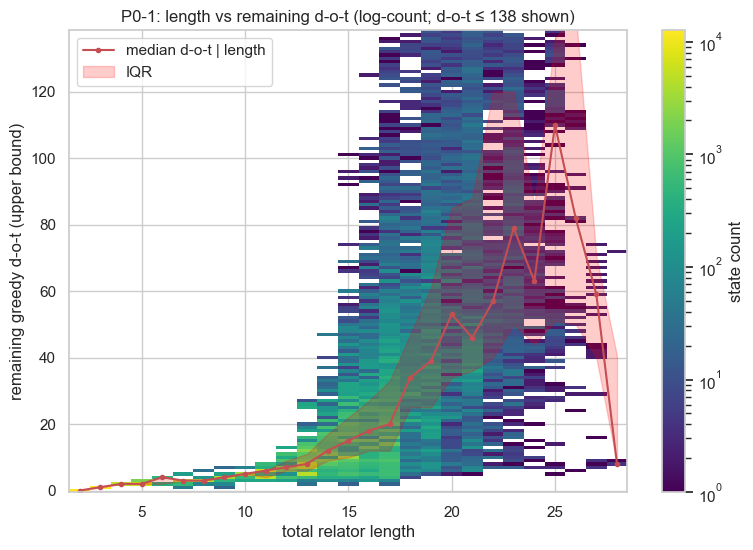

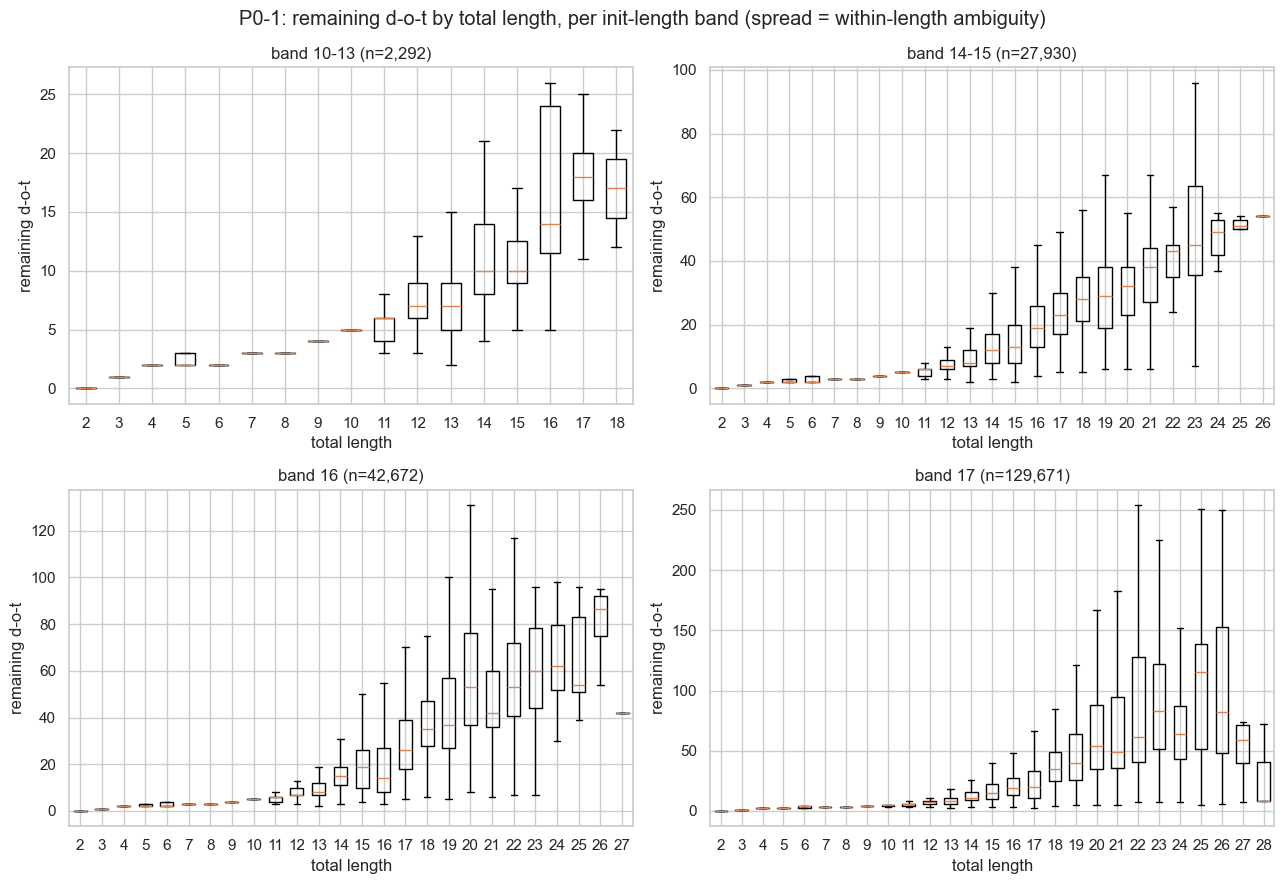

In [38]:
# ===== P0-1: Fair test — length vs remaining greedy d-o-t (UPPER BOUND on true d-o-t) =====
from matplotlib.colors import LogNorm

def eta_sq(x, y):
    """Correlation ratio: fraction of Var(y) explained by grouping on x (assumption-light)."""
    d = pd.DataFrame({"x": np.asarray(x), "y": np.asarray(y)}); grand = d["y"].mean()
    g = d.groupby("x")["y"]; ssb = (g.count()*(g.mean()-grand)**2).sum(); sst = ((d["y"]-grand)**2).sum()
    return ssb/sst if sst > 0 else np.nan

def spearman(a, b):  # scipy-free Spearman = Pearson correlation of ranks
    a, b = pd.Series(np.asarray(a)), pd.Series(np.asarray(b))
    return a.rank().corr(b.rank())

def fair_stats(s):
    return pd.Series({"n_states": len(s),
                      "Spearman rho": spearman(s["total_len"], s["remaining_dot"]),
                      "Pearson r": s["total_len"].corr(s["remaining_dot"]),
                      "eta^2": eta_sq(s["total_len"], s["remaining_dot"])})

tbl = [("ALL",) + tuple(fair_stats(on_path_states))]
for band in BAND_ORDER:
    tbl.append((band,) + tuple(fair_stats(on_path_states[on_path_states["init_len_band"] == band])))
fair_tbl = pd.DataFrame(tbl, columns=["band","n_states","Spearman rho","Pearson r","eta^2"]).set_index("band")
print("=== P0-1: length vs remaining greedy d-o-t (upper bound) ===")
print(fair_tbl.round(3).to_string())

cond = on_path_states.groupby("total_len")["remaining_dot"].agg(
    n="size", median="median", q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75))
cond["IQR"] = cond["q75"] - cond["q25"]
print("\nmean within-length IQR (state-weighted):",
      round((cond["IQR"]*cond["n"]).sum()/cond["n"].sum(), 2), "moves  <- ambiguity length cannot resolve")

fig, ax = plt.subplots(figsize=(9, 6))
ycap = int(on_path_states["remaining_dot"].quantile(.99)); m = on_path_states["remaining_dot"] <= ycap
h = ax.hist2d(on_path_states.loc[m,"total_len"], on_path_states.loc[m,"remaining_dot"],
              bins=[np.arange(1.5, on_path_states["total_len"].max()+1.5), np.arange(-0.5, ycap+1.5)],
              cmap="viridis", norm=LogNorm())
ax.plot(cond.index, cond["median"], "r-o", ms=3, label="median d-o-t | length")
ax.fill_between(cond.index, cond["q25"], cond["q75"], color="red", alpha=0.2, label="IQR")
ax.set_ylim(-0.5, ycap+0.5); ax.set_xlabel("total relator length")
ax.set_ylabel("remaining greedy d-o-t (upper bound)")
ax.set_title(f"P0-1: length vs remaining d-o-t (log-count; d-o-t ≤ {ycap} shown)")
ax.legend(); fig.colorbar(h[3], ax=ax, label="state count"); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, band in zip(axes.ravel(), BAND_ORDER):
    sub = on_path_states[on_path_states["init_len_band"] == band]
    lens = sorted(sub["total_len"].unique())
    ax.boxplot([sub.loc[sub["total_len"]==L, "remaining_dot"].values for L in lens],
               positions=lens, widths=0.6, showfliers=False)
    ax.set_title(f"band {band} (n={len(sub):,})"); ax.set_xlabel("total length"); ax.set_ylabel("remaining d-o-t")
fig.suptitle("P0-1: remaining d-o-t by total length, per init-length band (spread = within-length ambiguity)")
fig.tight_layout(); plt.show()

## P0-2 · How often & how much is greedy forced uphill in length?

Greedy's priority **is** total length, so any step that increases length is *forced* — the frontier offered nothing shorter. Per path we count: does it ever rise above its start (`Ever Above Start`), how many separate **uphill segments** (`Δ>0` runs), and the **total uphill work** (Σ of positive Δ) — all stratified by init-length band. This quantifies, fairly, the slice of the space where length actively misleads the search vs. where it descends monotonically.

=== P0-2: forced uphill by band ===
                  n  frac_ever_above  frac_step_increase  mean_uphill_segs  p90_uphill_segs  mean_max_rise  mean_uphill_work
init_len_band                                                                                                               
10-13           290            0.203               0.348             0.624              2.0          0.397             0.986
14-15          2254            0.238               0.505             1.767              6.0          0.697             3.203
16             2951            0.210               0.517             2.508              8.0          0.660             4.189
17             7186            0.299               0.625             3.306             10.0          1.071             6.815

overall fraction of solved paths that EVER rise above start: 0.2654


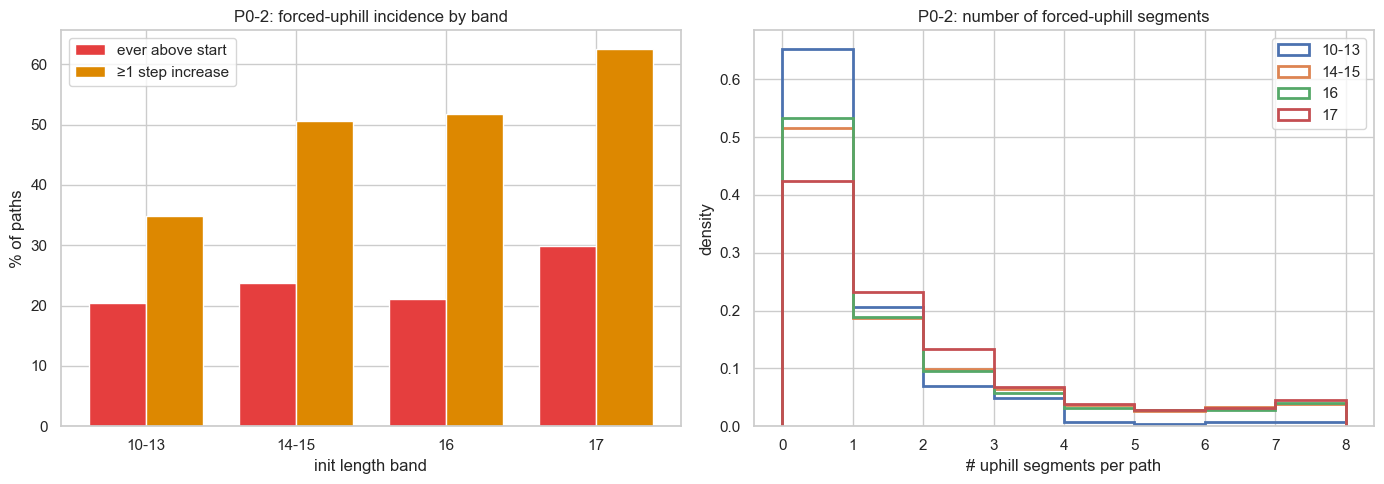

In [39]:
# ===== P0-2: forced-uphill incidence & magnitude, by init-length band =====
def uphill_metrics(profile):
    p = np.array(profile); d = np.diff(p); up = d > 0
    seg = int(np.sum(up & ~np.concatenate([[False], up[:-1]])))          # # of maximal Δ>0 runs
    above = p > p[0]; exc = int(np.sum(above & ~np.concatenate([[False], above[:-1]])))  # # excursions above start
    return seg, exc, int(d[d > 0].sum())                                  # uphill work = Σ positive Δ

um = length_profile_df["Length Profile"].map(uphill_metrics)
length_profile_df["Uphill Segments"]      = [x[0] for x in um]
length_profile_df["Excursions Above Start"] = [x[1] for x in um]
length_profile_df["Total Uphill Work"]    = [x[2] for x in um]
length_profile_df["init_len_band"] = pd.Categorical(
    length_profile_df["Start Total Length"].map(to_band), categories=BAND_ORDER, ordered=True)

agg = length_profile_df.groupby("init_len_band", observed=True).agg(
    n=("Ever Above Start","size"), frac_ever_above=("Ever Above Start","mean"),
    frac_step_increase=("Has Step Increase","mean"), mean_uphill_segs=("Uphill Segments","mean"),
    p90_uphill_segs=("Uphill Segments", lambda s: s.quantile(.9)),
    mean_max_rise=("Max Rise Above Start","mean"), mean_uphill_work=("Total Uphill Work","mean"))
print("=== P0-2: forced uphill by band ===")
print(agg.round(3).to_string())
print("\noverall fraction of solved paths that EVER rise above start:",
      round(length_profile_df["Ever Above Start"].mean(), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); x = np.arange(len(BAND_ORDER)); w = 0.38
axes[0].bar(x-w/2, agg["frac_ever_above"]*100, w, label="ever above start", color="#e53e3e")
axes[0].bar(x+w/2, agg["frac_step_increase"]*100, w, label="≥1 step increase", color="#dd8800")
axes[0].set_xticks(x); axes[0].set_xticklabels(BAND_ORDER); axes[0].set_xlabel("init length band")
axes[0].set_ylabel("% of paths"); axes[0].set_title("P0-2: forced-uphill incidence by band"); axes[0].legend()
for band in BAND_ORDER:
    s = length_profile_df.loc[length_profile_df["init_len_band"]==band, "Uphill Segments"]
    axes[1].hist(s, bins=range(0, 9), histtype="step", lw=2, density=True, label=band)
axes[1].set_xlabel("# uphill segments per path"); axes[1].set_ylabel("density")
axes[1].set_title("P0-2: number of forced-uphill segments"); axes[1].legend()
fig.tight_layout(); plt.show()

## P0-3 · Cross-path consistency & dedup (label hygiene)

The same state recurs across many presentations' paths. Grouping by `state_key`, we ask: how much does the data collapse, and do shared states carry **consistent** greedy d-o-t? **Finding (verified):** 202,565 on-path states collapse to ~25,209 unique states with **zero** cross-path d-o-t disagreement — greedy d-o-t is a consistent function of the state. So *within greedy data* min-aggregation is a no-op; it becomes necessary only once **shorter non-greedy (PPO/beam) paths** are added, which can lower a state's d-o-t. (Even the agreed value is an upper bound on true d-o-t.)

=== P0-3: cross-path consistency & dedup ===
pooled on-path states: 202,565  ->  unique state keys: 25,209  (8.0x redundancy)
fraction of unique states shared by >=2 paths: 0.4521
state keys with >1 distinct d-o-t (DISAGREEMENT): 0
=> greedy d-o-t is a CONSISTENT function of the state (zero cross-path disagreement).
   min-aggregation is a no-op within greedy data; needed only once SHORTER non-greedy
   (PPO/beam) paths are added, which can lower a state's d-o-t.

dedup'd per-state d-o-t label distribution (an upper bound on true d-o-t):
count    25209.0
mean        31.6
std         42.7
min          0.0
25%          7.0
50%         14.0
75%         38.0
max        349.0


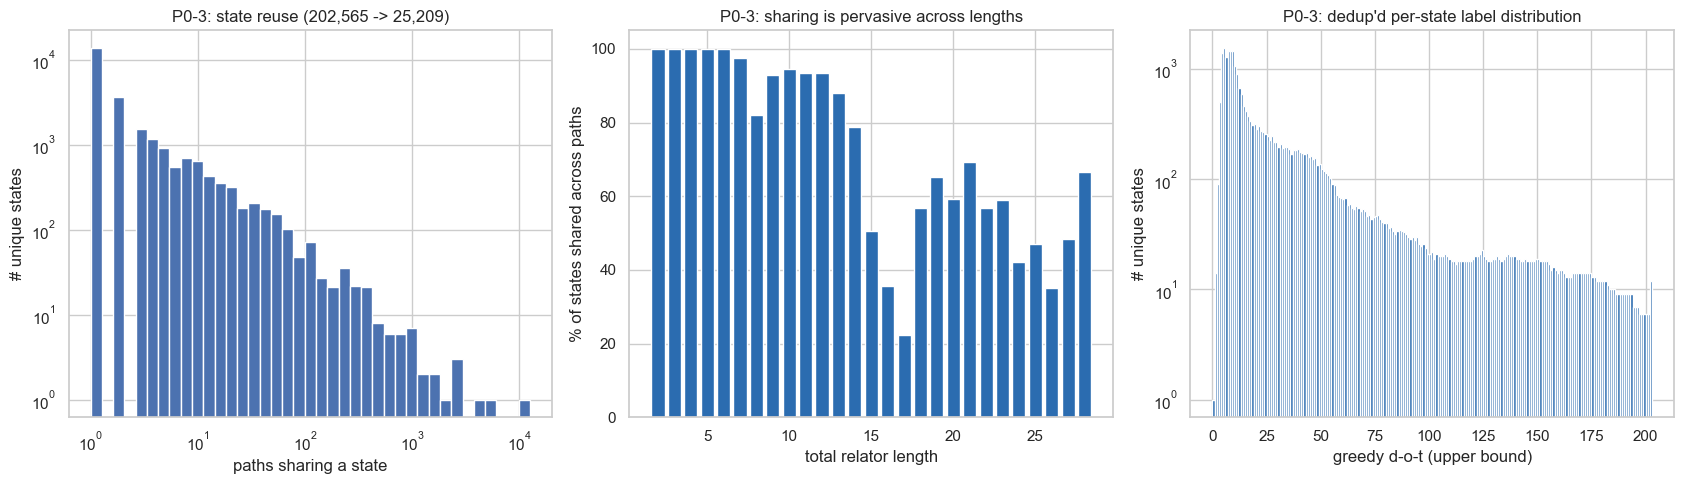

In [40]:
# ===== P0-3: cross-path consistency & dedup =====
g = on_path_states.groupby("state_key")
key_stats = pd.DataFrame({
    "multiplicity":   g["path_id"].nunique(),
    "n_distinct_dot": g["remaining_dot"].nunique(),
    "dot":            g["remaining_dot"].first(),
    "total_len":      g["total_len"].first()})
n_pool, n_keys = len(on_path_states), len(key_stats)
print("=== P0-3: cross-path consistency & dedup ===")
print(f"pooled on-path states: {n_pool:,}  ->  unique state keys: {n_keys:,}  ({n_pool/n_keys:.1f}x redundancy)")
print("fraction of unique states shared by >=2 paths:", round((key_stats["multiplicity"]>=2).mean(), 4))
print("state keys with >1 distinct d-o-t (DISAGREEMENT):", int((key_stats["n_distinct_dot"]>1).sum()))
print("=> greedy d-o-t is a CONSISTENT function of the state (zero cross-path disagreement).")
print("   min-aggregation is a no-op within greedy data; needed only once SHORTER non-greedy")
print("   (PPO/beam) paths are added, which can lower a state's d-o-t.")
print("\ndedup'd per-state d-o-t label distribution (an upper bound on true d-o-t):")
print(key_stats["dot"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].hist(key_stats["multiplicity"], bins=np.logspace(0, np.log10(key_stats["multiplicity"].max()+1), 40))
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("paths sharing a state")
axes[0].set_ylabel("# unique states"); axes[0].set_title(f"P0-3: state reuse ({n_pool:,} -> {n_keys:,})")
frac_shared = (key_stats["multiplicity"]>=2).groupby(key_stats["total_len"]).mean()
axes[1].bar(frac_shared.index, frac_shared.values*100, color="#2b6cb0")
axes[1].set_xlabel("total relator length"); axes[1].set_ylabel("% of states shared across paths")
axes[1].set_title("P0-3: sharing is pervasive across lengths")
axes[2].hist(key_stats["dot"], bins=range(0, int(key_stats["dot"].quantile(.99))+2), color="#2b6cb0")
axes[2].set_yscale("log"); axes[2].set_xlabel("greedy d-o-t (upper bound)"); axes[2].set_ylabel("# unique states")
axes[2].set_title("P0-3: dedup'd per-state label distribution")
fig.tight_layout(); plt.show()

## P1-4 · Per-step length deltas — where does length give no descent signal?

At the move level: the per-step change in total length, and the share of steps that are **flat-or-up** (length offers no descent). Stratified by remaining-d-o-t bucket to see whether the no-signal steps concentrate far from the goal — the regime where length carries the least gradient.

=== P1-4: per-step length deltas ===  transitions: 189884
delta
down    68.32
up      24.02
flat     7.66
non-decreasing-step share (flat+up, no descent signal): 31.68%

step-direction % by remaining-d-o-t bucket:
delta           down  flat    up
remaining_dot                   
0-2            100.0   0.0   0.0
3-5             97.5   0.7   1.8
6-10            67.7  11.7  20.6
11-20           53.4   7.7  38.9
21+             43.9  12.9  43.2


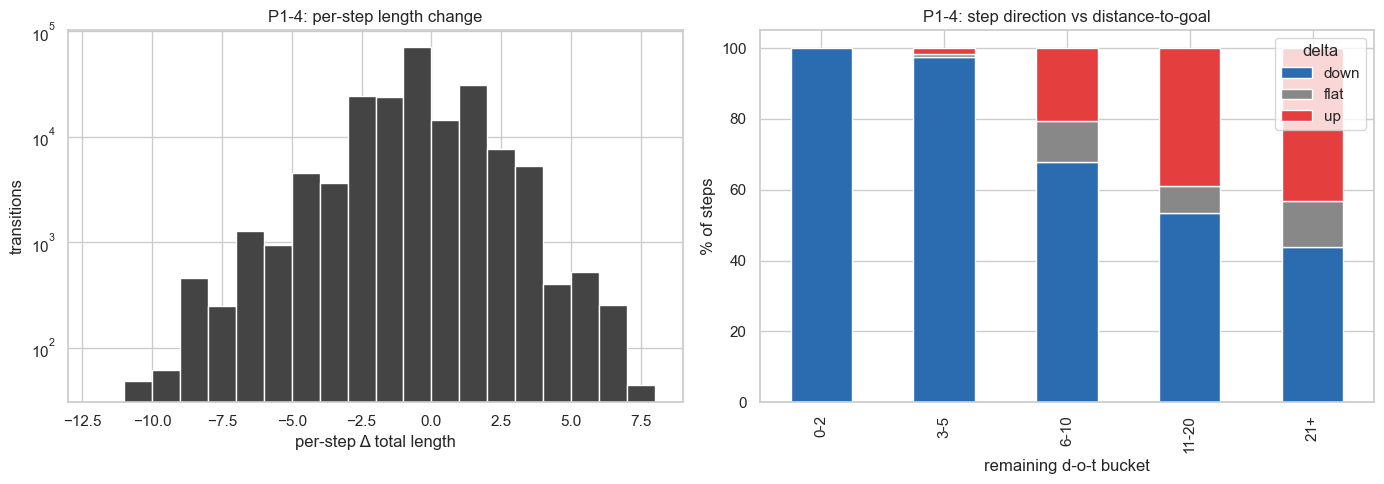

In [41]:
# ===== P1-4: per-step length-delta distribution =====
ops = on_path_states.sort_values(["path_id","step_index"]).copy()
ops["next_total"] = ops.groupby("path_id")["total_len"].shift(-1)
trans = ops.dropna(subset=["next_total"]).copy()
trans["delta"] = (trans["next_total"] - trans["total_len"]).astype(int)
sign = pd.cut(trans["delta"], [-99, -0.5, 0.5, 99], labels=["down","flat","up"])
print("=== P1-4: per-step length deltas ===  transitions:", len(trans))
print((sign.value_counts(normalize=True)*100).round(2).to_string())
print("non-decreasing-step share (flat+up, no descent signal): {:.2f}%".format((trans["delta"]>=0).mean()*100))
rd = pd.cut(trans["remaining_dot"], [-1,2,5,10,20,9999], labels=["0-2","3-5","6-10","11-20","21+"])
ct = pd.crosstab(rd, sign, normalize="index")*100
print("\nstep-direction % by remaining-d-o-t bucket:")
print(ct.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(trans["delta"], bins=range(int(trans["delta"].min())-1, int(trans["delta"].max())+2), color="#444")
axes[0].set_yscale("log"); axes[0].set_xlabel("per-step Δ total length"); axes[0].set_ylabel("transitions")
axes[0].set_title("P1-4: per-step length change")
ct.plot(kind="bar", stacked=True, ax=axes[1], color={"down":"#2b6cb0","flat":"#888","up":"#e53e3e"})
axes[1].set_xlabel("remaining d-o-t bucket"); axes[1].set_ylabel("% of steps")
axes[1].set_title("P1-4: step direction vs distance-to-goal"); fig.tight_layout(); plt.show()

## P1-5 · Within-path: does length rank progress correctly?

Per trajectory, Spearman(total_len, remaining_dot). Since remaining_dot is strictly monotone in step, this is +1 exactly when the length profile is monotone-nonincreasing and degrades with humps/plateaus — a search-flavoured complement to P0-1's pooled view. The distribution shows length is a near-perfect progress ranker on most paths; the low-ρ tail localizes where a heuristic would have to *disagree* with length to help.

=== P1-5: within-path length-as-progress-ranker quality ===
paths with defined rho: 12681 | median rho: 0.976 | frac >= 0.95: 0.651
                  n  median  frac_ge_0_95
init_len_band                            
10-13           290   1.000         0.772
14-15          2254   0.986         0.674
16             2951   0.984         0.712
17             7186   0.971         0.615


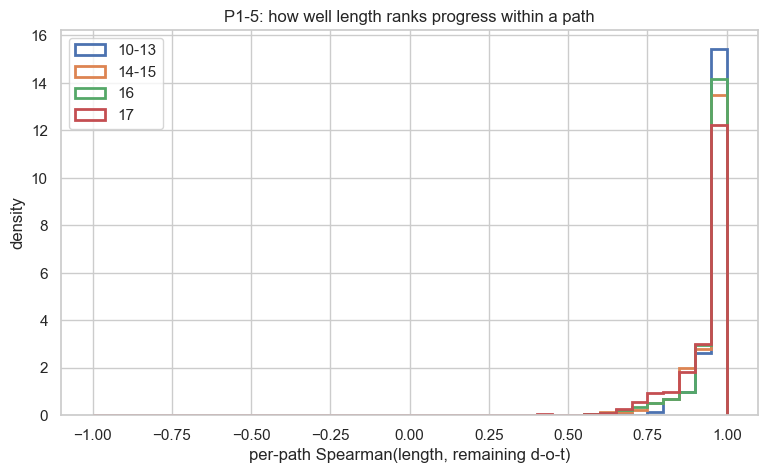

In [42]:
# ===== P1-5: within-path Spearman(length, remaining d-o-t) =====
def path_spearman(profile):
    p = np.array(profile, float)
    if len(p) < 2 or p.min() == p.max(): return np.nan
    rdot = np.arange(len(p)-1, -1, -1)            # remaining_dot is strictly monotone in step
    return pd.Series(p).rank().corr(pd.Series(rdot).rank())

length_profile_df["within_path_spearman"] = length_profile_df["Length Profile"].map(path_spearman)
wp = length_profile_df.dropna(subset=["within_path_spearman"])
print("=== P1-5: within-path length-as-progress-ranker quality ===")
print("paths with defined rho:", len(wp), "| median rho:", round(wp["within_path_spearman"].median(), 3),
      "| frac >= 0.95:", round((wp["within_path_spearman"]>=0.95).mean(), 3))
print(wp.groupby("init_len_band", observed=True)["within_path_spearman"].agg(
    n="size", median="median", frac_ge_0_95=lambda s: (s>=0.95).mean()).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
for band in BAND_ORDER:
    ax.hist(wp.loc[wp["init_len_band"]==band, "within_path_spearman"], bins=np.linspace(-1, 1, 41),
            histtype="step", lw=2, density=True, label=band)
ax.set_xlabel("per-path Spearman(length, remaining d-o-t)"); ax.set_ylabel("density")
ax.set_title("P1-5: how well length ranks progress within a path"); ax.legend(); plt.show()

## P1-6 · Length-profile archetypes

Classify each solved path by its number of uphill segments: **monotone-down** (U=0), **single-hump** (U=1), **multi-hump** (U≥2), with a plateau-heavy flag. The multi-hump share (and how it grows with initial length) marks the structurally non-monotone regime where length under-determines progress.

=== P1-6: archetypes ===
archetype
monotone-down    42.77
multi-hump       38.00
single-hump      19.23
plateau-heavy (>=50% flat steps): 0.20%

archetype % by band:
archetype      monotone-down  multi-hump  single-hump
init_len_band                                        
10-13                   65.2        14.1         20.7
14-15                   49.5        32.6         18.0
16                      48.3        34.7         17.0
17                      37.5        42.0         20.5


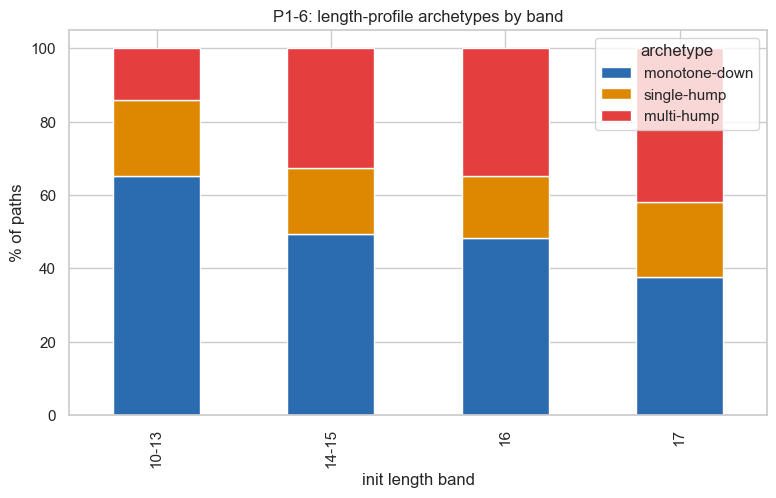

In [43]:
# ===== P1-6: length-profile archetypes =====
length_profile_df["plateau_frac"] = length_profile_df["Length Profile"].map(
    lambda p: float((np.diff(np.array(p))==0).mean()) if len(p) > 1 else 0.0)
length_profile_df["archetype"] = length_profile_df["Uphill Segments"].map(
    lambda u: "monotone-down" if u == 0 else ("single-hump" if u == 1 else "multi-hump"))
print("=== P1-6: archetypes ===")
print((length_profile_df["archetype"].value_counts(normalize=True)*100).round(2).to_string())
print("plateau-heavy (>=50% flat steps): {:.2f}%".format(length_profile_df["plateau_frac"].ge(0.5).mean()*100))
xt = pd.crosstab(length_profile_df["init_len_band"], length_profile_df["archetype"], normalize="index")*100
print("\narchetype % by band:")
print(xt.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
xt[["monotone-down","single-hump","multi-hump"]].plot(kind="bar", stacked=True, ax=ax,
    color={"monotone-down":"#2b6cb0","single-hump":"#dd8800","multi-hump":"#e53e3e"})
ax.set_ylabel("% of paths"); ax.set_xlabel("init length band")
ax.set_title("P1-6: length-profile archetypes by band"); plt.show()

## P1-7 · Relator-length asymmetry — a within-length feature length discards

Two states with the *same* total length can have very different `|len(r1) − len(r2)|`. We track asymmetry goal-aligned (binned by remaining d-o-t) and within fixed total length. Framed strictly as a **candidate feature** the current heuristic ignores — **not** evidence that d-o-t wins.

=== P1-7: relator-length asymmetry by distance-to-goal ===
                   n  mean  median
remaining_dot                     
0              12681  0.00     0.0
1-2            25362  1.33     1.0
3-5            36089  1.85     1.0
6-10           39827  1.95     1.0
11-20          34714  1.94     2.0
21+            53892  3.09     3.0


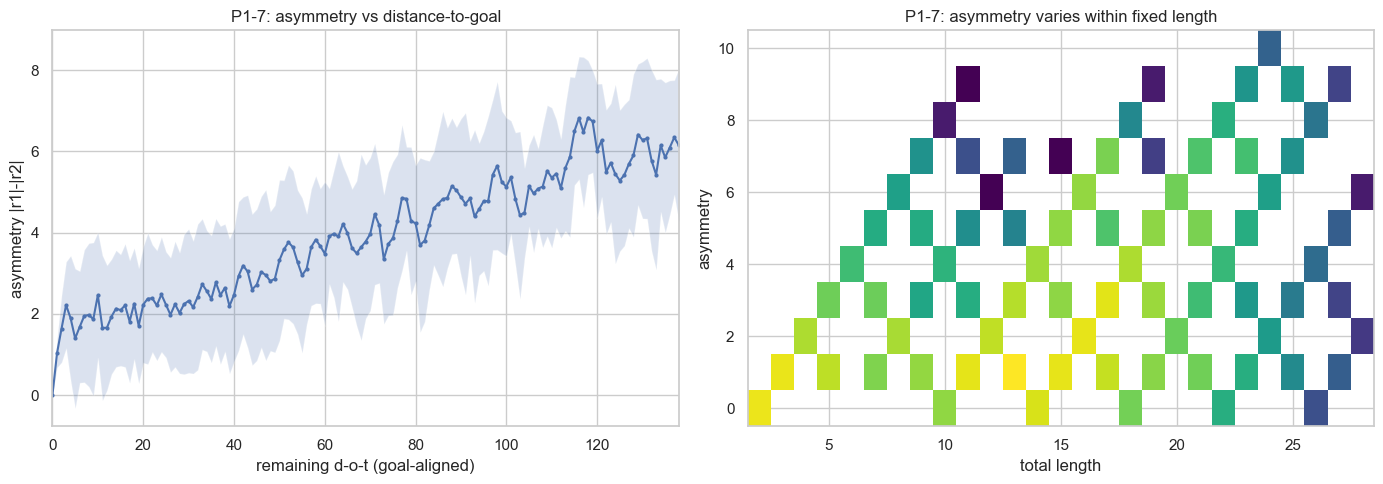

In [44]:
# ===== P1-7: relator-length asymmetry |len(r1)-len(r2)| =====
from matplotlib.colors import LogNorm
rb = pd.cut(on_path_states["remaining_dot"], [-1,0,2,5,10,20,9999],
            labels=["0","1-2","3-5","6-10","11-20","21+"])
print("=== P1-7: relator-length asymmetry by distance-to-goal ===")
print(on_path_states.groupby(rb, observed=True)["asym"].agg(n="size", mean="mean", median="median").round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ag = on_path_states.groupby("remaining_dot")["asym"].agg(["mean","std","size"]); ag = ag[ag["size"] >= 30]
axes[0].plot(ag.index, ag["mean"], "-o", ms=2)
axes[0].fill_between(ag.index, ag["mean"]-ag["std"], ag["mean"]+ag["std"], alpha=0.2)
axes[0].set_xlim(0, int(on_path_states["remaining_dot"].quantile(.99)))
axes[0].set_xlabel("remaining d-o-t (goal-aligned)"); axes[0].set_ylabel("asymmetry |r1|-|r2|")
axes[0].set_title("P1-7: asymmetry vs distance-to-goal")
tlmax = int(on_path_states["total_len"].max())
axes[1].hist2d(on_path_states["total_len"], on_path_states["asym"],
               bins=[np.arange(1.5, tlmax+1.5), np.arange(-0.5, on_path_states["asym"].max()+1.5)],
               cmap="viridis", norm=LogNorm())
axes[1].set_xlabel("total length"); axes[1].set_ylabel("asymmetry")
axes[1].set_title("P1-7: asymmetry varies within fixed length"); fig.tight_layout(); plt.show()

## P1-8 · Censored / unsolved rows — right-censored d-o-t

The 4,954 unsolved presentations have only `(r1, r2)` (d-o-t unknown, beyond greedy's budget) — **right-censored** labels, to be modeled as "d-o-t > budget", not large finite values. We characterise their initial length and asymmetry vs solved. **Caveat:** greedy *uses* length, so "unsolved" is entangled with the node budget — it is not a clean property of the length heuristic.

=== P1-8: unsolved = right-censored d-o-t (label > budget) ===
           n  unsolved_rate
band                       
10-13    298          0.027
14-15   2540          0.113
16      3610          0.183
17     11187          0.358

initial asymmetry  mean(solved): 3.746  mean(unsolved): 2.183  <- unsolved are MORE balanced
Caveat: greedy uses length, so 'unsolved' is entangled with the node budget; these are
censored labels, not large finite distances.


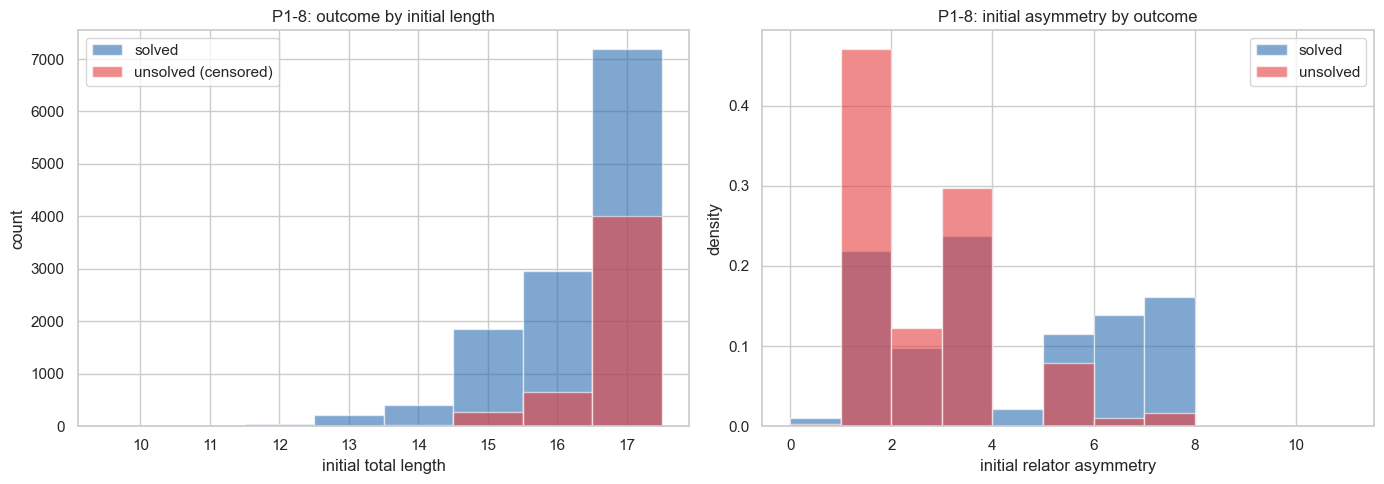

In [45]:
# ===== P1-8: censored / unsolved-row characterization =====
dfc = df.copy()
dfc["init_total"] = dfc["r1"].str.len() + dfc["r2"].str.len()
dfc["init_asym"]  = (dfc["r1"].str.len() - dfc["r2"].str.len()).abs()
dfc["solved"]     = dfc["Path Length"] >= 0
dfc["band"]       = pd.Categorical(dfc["init_total"].map(to_band), categories=BAND_ORDER, ordered=True)
print("=== P1-8: unsolved = right-censored d-o-t (label > budget) ===")
print(dfc.groupby("band", observed=True)["solved"].agg(
    n="size", unsolved_rate=lambda s: 1 - s.mean()).round(3).to_string())
print("\ninitial asymmetry  mean(solved):", round(dfc.loc[dfc.solved,"init_asym"].mean(), 3),
      " mean(unsolved):", round(dfc.loc[~dfc.solved,"init_asym"].mean(), 3),
      " <- unsolved are MORE balanced")
print("Caveat: greedy uses length, so 'unsolved' is entangled with the node budget; these are")
print("censored labels, not large finite distances.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.arange(dfc["init_total"].min()-0.5, dfc["init_total"].max()+1.5)
axes[0].hist(dfc.loc[dfc.solved,"init_total"], bins=bins, alpha=0.6, label="solved", color="#2b6cb0")
axes[0].hist(dfc.loc[~dfc.solved,"init_total"], bins=bins, alpha=0.6, label="unsolved (censored)", color="#e53e3e")
axes[0].set_xlabel("initial total length"); axes[0].set_ylabel("count")
axes[0].set_title("P1-8: outcome by initial length"); axes[0].legend()
axes[1].hist(dfc.loc[dfc.solved,"init_asym"], bins=range(0,12), alpha=0.6, density=True, label="solved", color="#2b6cb0")
axes[1].hist(dfc.loc[~dfc.solved,"init_asym"], bins=range(0,12), alpha=0.6, density=True, label="unsolved", color="#e53e3e")
axes[1].set_xlabel("initial relator asymmetry"); axes[1].set_ylabel("density")
axes[1].set_title("P1-8: initial asymmetry by outcome"); axes[1].legend(); fig.tight_layout(); plt.show()

## P2-9 · Length-only predictability headroom (FENCED)

The best a length-only predictor can do: within-band conditional median of remaining d-o-t given total length, MAE vs. a band-constant baseline (floor = 0). **Fence:** the residual MAE is an **upper bound** on the room a richer feature *could* recover — it is necessary-not-sufficient and does **not** show any model (d-o-t or otherwise) realizes that room. No "d-o-t would cut error by X" claims.

=== P2-9: length-only predictor error (FENCED) ===
            n  MAE_const  MAE_len_cond
band                                  
10-13    2292      2.862         0.966
14-15   27930      7.011         3.353
16      42672     10.500         5.395
17     129671     17.492        10.095

FENCE: MAE_len_cond is what a PERFECT length->d-o-t lookup still gets wrong — an UPPER
BOUND on the room a richer feature COULD recover (necessary, not sufficient). It does NOT
show any model actually realizes that room.


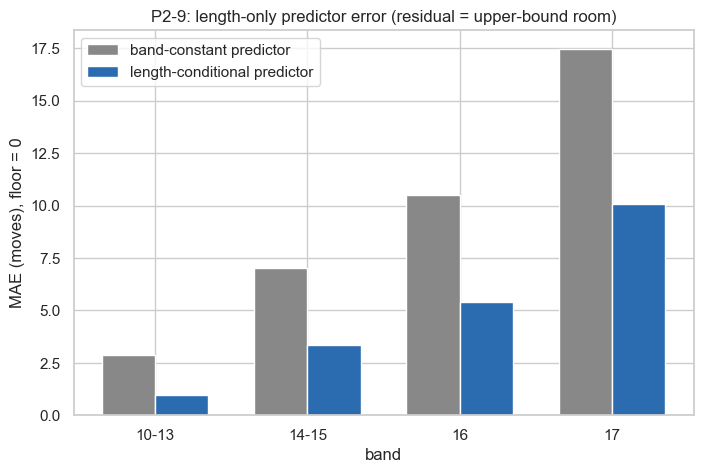

In [46]:
# ===== P2-9: length-only predictability headroom (FENCED) =====
rowsh = []
for band in BAND_ORDER:
    sub = on_path_states[on_path_states["init_len_band"] == band]
    mae_const = (sub["remaining_dot"] - sub["remaining_dot"].median()).abs().mean()
    cond_med  = sub.groupby("total_len")["remaining_dot"].transform("median")
    mae_len   = (sub["remaining_dot"] - cond_med).abs().mean()
    rowsh.append((band, len(sub), mae_const, mae_len))
head = pd.DataFrame(rowsh, columns=["band","n","MAE_const","MAE_len_cond"]).set_index("band")
print("=== P2-9: length-only predictor error (FENCED) ===")
print(head.round(3).to_string())
print("\nFENCE: MAE_len_cond is what a PERFECT length->d-o-t lookup still gets wrong — an UPPER")
print("BOUND on the room a richer feature COULD recover (necessary, not sufficient). It does NOT")
print("show any model actually realizes that room.")

fig, ax = plt.subplots(figsize=(8, 5)); x = np.arange(len(BAND_ORDER)); w = 0.35
ax.bar(x-w/2, head["MAE_const"], w, label="band-constant predictor", color="#888")
ax.bar(x+w/2, head["MAE_len_cond"], w, label="length-conditional predictor", color="#2b6cb0")
ax.set_xticks(x); ax.set_xticklabels(BAND_ORDER); ax.set_ylabel("MAE (moves), floor = 0"); ax.set_xlabel("band")
ax.set_title("P2-9: length-only predictor error (residual = upper-bound room)"); ax.legend(); plt.show()

## P2-10 · Last-mile / point-of-no-return

Per path: the monotone-nonincreasing **suffix fraction** (how late length becomes a clean signal) and the **d-o-t at the last local max** (how deep the point-of-no-return sits). Length is a reliably monotone signal only over the final part of the trajectory; the earlier segment is where non-monotonicity lives.

=== P2-10: how late does length become a clean (monotone) signal? ===
median monotone-suffix fraction: 0.7 | median d-o-t at point-of-no-return: 5.0
init_len_band
10-13    1.000
14-15    0.889
16       0.818
17       0.625


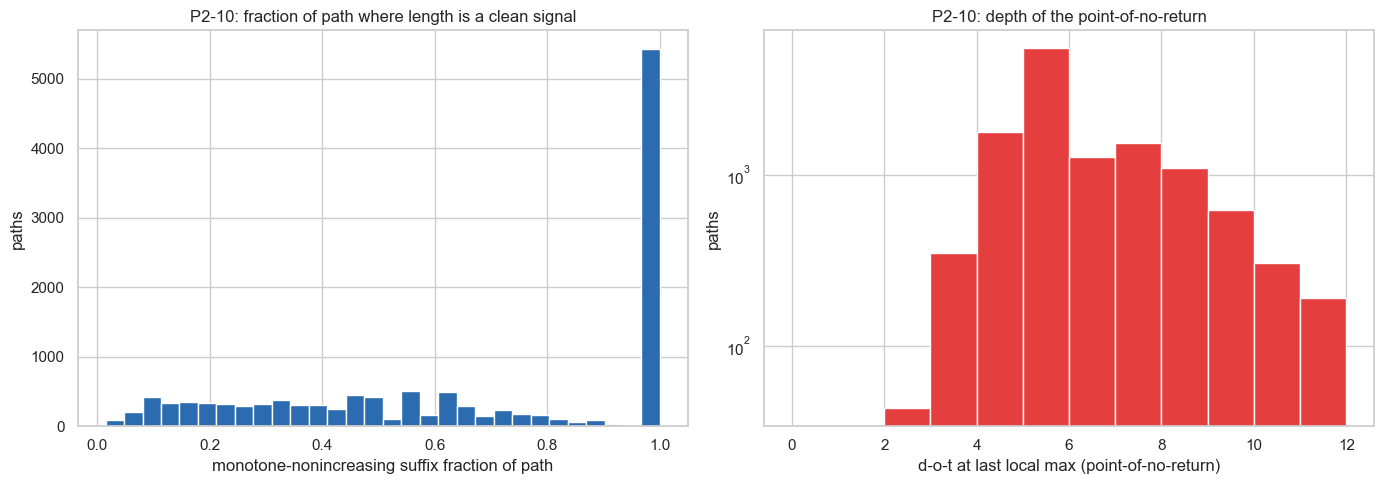

In [47]:
# ===== P2-10: last-mile / point-of-no-return =====
def last_mile(profile):
    p = np.array(profile); n = len(p)
    if n < 2: return 1.0, 0
    k = n - 1
    while k > 0 and p[k-1] >= p[k]: k -= 1       # longest monotone-nonincreasing suffix starts at k
    return (n-1-k)/(n-1), (n-1) - k               # suffix fraction, remaining d-o-t at the last local max

lm = length_profile_df["Length Profile"].map(last_mile)
length_profile_df["monotone_suffix_frac"] = [x[0] for x in lm]
length_profile_df["dot_at_last_max"]      = [x[1] for x in lm]
print("=== P2-10: how late does length become a clean (monotone) signal? ===")
print("median monotone-suffix fraction:", round(length_profile_df["monotone_suffix_frac"].median(), 3),
      "| median d-o-t at point-of-no-return:", round(length_profile_df["dot_at_last_max"].median(), 1))
print(length_profile_df.groupby("init_len_band", observed=True)["monotone_suffix_frac"].median().round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(length_profile_df["monotone_suffix_frac"], bins=30, color="#2b6cb0")
axes[0].set_xlabel("monotone-nonincreasing suffix fraction of path"); axes[0].set_ylabel("paths")
axes[0].set_title("P2-10: fraction of path where length is a clean signal")
axes[1].hist(length_profile_df["dot_at_last_max"],
             bins=range(0, int(length_profile_df["dot_at_last_max"].quantile(.99))+2), color="#e53e3e")
axes[1].set_yscale("log"); axes[1].set_xlabel("d-o-t at last local max (point-of-no-return)"); axes[1].set_ylabel("paths")
axes[1].set_title("P2-10: depth of the point-of-no-return"); fig.tight_layout(); plt.show()

## P2-11 · Neighbor resolution — does length discriminate among real sibling moves? (heavy)

A search heuristic ranks *neighbors*, not on-path states. This tab **ports the lab's `get_neighbors_nj` from `greedy_search.ipynb`** (numba `@njit` stripped) and, for a stratified sample of states, expands the actual S-move successors, canonicalises each via `canonical_pair_nj`, and ranks them by total length. We report: **tie multiplicity at the length-argmin** (how many moves look equally good to length), whether greedy's chosen move is a length-argmin, and — where d-o-t is known — whether the shortest neighbor is also the closest-to-trivial. *Two notes:* (1) 100% neighbor coverage of the actual next state validates the port; this also verifies the stored keys are **1:1 with true `canonical_pair_nj` classes**. (2) **Blind spot:** off-path neighbors have unknown d-o-t, so the dot-agreement metric is partial. Runtime ≈ 1 min.

stored state keys: 25,209  ->  true canonical_pair_nj classes: 25,209  (overcount 1.00x) -- stored keys are 1:1 with canonical classes

expanding S-move neighbors for 3,200 sampled states (~1 min)...
neighbor-set coverage of the actual next state: 3200/3200 (100.0%)  (validates port)

=== P2-11 results ===
median distinct canonical neighbors per state: 24
median tie multiplicity at length-argmin: 1 | mean: 1.8
fraction of states with >=2 neighbors TIED at min length: 0.413
fraction where greedy's actual move is a length-argmin: 0.853

by band (dot_agree is PARTIAL: off-path neighbors have unknown d-o-t):
         n  med_neigh  mean_tie  next_is_argmin  dot_agree
band                                                      
10-13  800       16.0     1.560           0.918      0.880
14-15  800       24.0     1.788           0.859      0.830
16     800       28.0     2.070           0.855      0.828
17     800       36.0     1.788           0.781      0.765


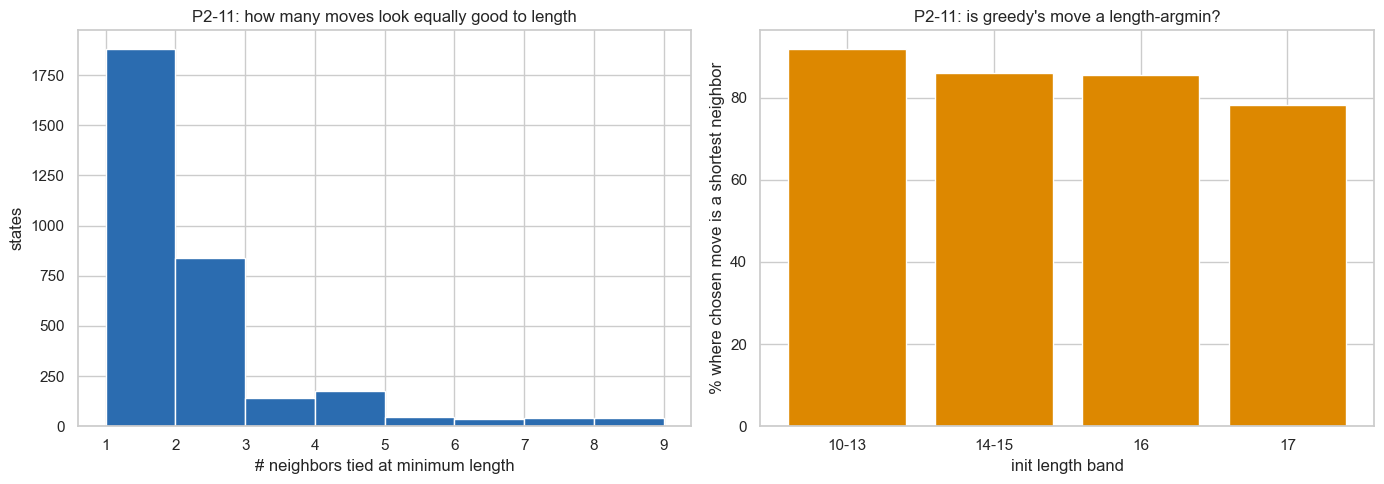

In [48]:
# ===== P2-11: neighbor resolution (ports lab's get_neighbors_nj, @njit stripped) =====
import json
from pathlib import Path as _P

_gs = _P("greedy_search.ipynb")
_src = next("".join(c["source"]) for c in json.load(_gs.open())["cells"]
            if c["cell_type"] == "code" and "def get_neighbors_nj" in "".join(c["source"]))
_clean = "\n".join(l for l in _src.splitlines() if not l.strip().startswith("@njit"))  # numba -> plain numpy
_ns = {"np": np}; exec(_clean, _ns)
str_to_arr, arr_to_str = _ns["str_to_arr"], _ns["arr_to_str"]
get_neighbors_nj, reduce_relator_nj, canonical_pair_nj = (
    _ns["get_neighbors_nj"], _ns["reduce_relator_nj"], _ns["canonical_pair_nj"])

def cpkey(arr1, arr2):                       # common TRUE-canonical key for matching representations
    c1, c2 = canonical_pair_nj(reduce_relator_nj(arr1), reduce_relator_nj(arr2))
    return arr_to_str(c1) + "|" + arr_to_str(c2), len(c1) + len(c2)

# map every distinct stored state -> true canonical key (verifies stored keys are 1:1 with canonical)
_d = on_path_states.drop_duplicates("state_key")
ck_of = {k: cpkey(str_to_arr(a), str_to_arr(b))[0]
         for k, a, b in zip(_d["state_key"], _d["r1_str"], _d["r2_str"])}
n_stored = on_path_states["state_key"].nunique(); n_canon = len(set(ck_of.values()))
print(f"stored state keys: {n_stored:,}  ->  true canonical_pair_nj classes: {n_canon:,}  "
      f"(overcount {n_stored/n_canon:.2f}x) -- stored keys are 1:1 with canonical classes")

# canonical-keyed d-o-t map (consistent; min is the eventual reducer once non-greedy paths join)
ops11 = on_path_states.sort_values(["path_id","step_index"]).copy()
ops11["ckey"]      = ops11["state_key"].map(ck_of)
ops11["next_skey"] = ops11.groupby("path_id")["state_key"].shift(-1)
ops11["next_ckey"] = ops11["next_skey"].map(ck_of)
dot_map = ops11.groupby("ckey")["remaining_dot"].min().to_dict()

# stratified sample of NON-terminal states (expansion is O(|r1|*|r2|) per state)
SAMPLE_PER_BAND = 800
nonterm = ops11[ops11["next_ckey"].notna()]
samp = pd.concat([
    nonterm[nonterm["init_len_band"] == b].sample(
        min(int((nonterm["init_len_band"] == b).sum()), SAMPLE_PER_BAND), random_state=0)
    for b in BAND_ORDER]).reset_index(drop=True)
print(f"\nexpanding S-move neighbors for {len(samp):,} sampled states (~1 min)...")

res = []; cover = 0; bad = 0
for r1s, r2s, next_ckey, band in zip(samp["r1_str"], samp["r2_str"], samp["next_ckey"], samp["init_len_band"]):
    neigh = {}
    for nr1, nr2 in get_neighbors_nj(str_to_arr(r1s), str_to_arr(r2s)):
        try: k, L = cpkey(nr1, nr2)
        except Exception: bad += 1; continue
        if L > 0: neigh[k] = L
    if not neigh: continue
    minL = min(neigh.values()); argmin = {k for k, L in neigh.items() if L == minL}
    cover += next_ckey in neigh
    known = {k: dot_map[k] for k in neigh if k in dot_map}
    dot_agree = np.nan
    if known:
        md = min(known.values()); dot_argmin = {k for k, d in known.items() if d == md}
        dot_agree = float(len(argmin & dot_argmin) > 0)
    res.append((band, len(neigh), len(argmin), next_ckey in argmin, dot_agree))

R = pd.DataFrame(res, columns=["band","n_neigh","tie_mult","next_is_lenargmin","dot_agree"])
R["band"] = pd.Categorical(R["band"], categories=BAND_ORDER, ordered=True)
print(f"neighbor-set coverage of the actual next state: {cover}/{len(samp)} ({100*cover/len(samp):.1f}%)  (validates port)")
print("\n=== P2-11 results ===")
print("median distinct canonical neighbors per state:", int(R["n_neigh"].median()))
print("median tie multiplicity at length-argmin:", int(R["tie_mult"].median()), "| mean:", round(R["tie_mult"].mean(), 2))
print("fraction of states with >=2 neighbors TIED at min length:", round((R["tie_mult"]>=2).mean(), 3))
print("fraction where greedy's actual move is a length-argmin:", round(R["next_is_lenargmin"].mean(), 3))
print("\nby band (dot_agree is PARTIAL: off-path neighbors have unknown d-o-t):")
print(R.groupby("band", observed=True).agg(
    n=("tie_mult","size"), med_neigh=("n_neigh","median"), mean_tie=("tie_mult","mean"),
    next_is_argmin=("next_is_lenargmin","mean"), dot_agree=("dot_agree","mean")).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(R["tie_mult"], bins=range(1, int(R["tie_mult"].quantile(.99))+2), color="#2b6cb0")
axes[0].set_xlabel("# neighbors tied at minimum length"); axes[0].set_ylabel("states")
axes[0].set_title("P2-11: how many moves look equally good to length")
nb = R.groupby("band", observed=True)["next_is_lenargmin"].mean().reindex(BAND_ORDER)*100
axes[1].bar(np.arange(len(BAND_ORDER)), nb.values, color="#dd8800")
axes[1].set_xticks(np.arange(len(BAND_ORDER))); axes[1].set_xticklabels(BAND_ORDER)
axes[1].set_xlabel("init length band"); axes[1].set_ylabel("% where chosen move is a shortest neighbor")
axes[1].set_title("P2-11: is greedy's move a length-argmin?"); fig.tight_layout(); plt.show()

# Synthesis — what this EDA says for the lab

**Dataset.** 17,635 GS-Sub presentations (initial length 10–17, 63 % at length 17); **12,681 solved** with full step-by-step paths, **4,954 unsolved** (right-censored d-o-t). All "d-o-t" below is **greedy** distance-to-trivial — an *upper bound* on true d-o-t.

**Where length (the incumbent heuristic) is strong:**
- It is a genuine monotone signal: pooled **Spearman ρ ≈ 0.91**, and on a *per-path* basis it ranks progress almost perfectly (**median within-path ρ ≈ 0.98**; 65 % of paths ≥ 0.95).
- **42.8 %** of solved paths descend **monotonically** in length — length never misleads them.

**Where length is uninformative (the headroom — stated without claiming d-o-t fills it):**
- At a **fixed** total length, remaining d-o-t still varies widely: **η² ≈ 0.54** (≈46 % of variance unexplained), with a within-length IQR of **~16 moves at length 17**. A perfect length-only lookup still mis-predicts by **MAE ≈ 10 moves** at length 17 (P2-9, fenced upper bound on room).
- Greedy is **forced above its start length in 26.5 %** of solved instances (30 % at length 17), in up to ~3 separate uphill segments rising as much as +11 — i.e. **38 % of paths are multi-hump** (42 % at length 17).
- **31.7 %** of individual moves are flat-or-up in length (no descent signal), concentrated far from the goal; length only becomes a reliably monotone signal over roughly the **last 60–70 %** of a path.
- At the actual decision point, **41 % of states have ≥2 neighbors tied at minimum length** (length can't break the tie), and greedy's chosen move is a shortest neighbor only **85 %** of the time (78 % at length 17).

**Label quality (good news).** The 202,565 on-path states collapse to **25,209 unique states with zero cross-path d-o-t disagreement** — greedy d-o-t is a consistent function of the state, giving a clean dedup'd (state → d-o-t) training set. Min-aggregation becomes necessary only once **shorter non-greedy (PPO/beam) paths** are added.

**Implications for the d-o-t model (next steps, not conclusions):**
1. Train on the dedup'd **25,209** unique states; transform the heavy-tailed target (`log1p`) and lead with **rank metrics**, stratified **by length band**.
2. Add **non-greedy (PPO/beam)** paths — they carry the length-increasing detours greedy avoids and will make min-aggregation bite.
3. Treat unsolved rows as **right-censored** (d-o-t > budget), not large finite labels; consider **asymmetry** (P1-7) as a candidate within-length feature.

**Honest bottom line:** total length is a strong, cheap heuristic with a *quantified* blind spot — within-length ambiguity, a forced-uphill regime, and unbreakable length-ties among sibling moves. **Whether a learned d-o-t heuristic actually fills that blind spot is the next experiment; this EDA scopes the opportunity, it does not prove the win.**